# Fannie Mae Mortgage Risk EDA

I started this notebook after the data wrangling step. The monthly loan panel is already built, so I am not going back to the raw acquisition and performance files here. My goal in this notebook is to understand the panel, check the target, and decide which fields are worth carrying into modeling.

The outcome I am using is `future_serious_dq_6m`. A row is positive when that loan becomes seriously delinquent sometime in the next six months.

The main things I wanted to answer were:

1. Does the loan-month panel look reasonable after wrangling?
2. How rare is the delinquency target?
3. Which features show the clearest relationship with the target?
4. Which features should be used, dropped, or checked for leakage before modeling?

I made sure every feature had at least one numeric review. For the stronger candidates, I also looked at relationship plots and association statistics so the feature choices are based on the data instead of only intuition.


In [1]:
from pathlib import Path
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

try:
    from scipy import stats
except ImportError:
    stats = None
    print("scipy is not installed, so p-values and Cramer's V will be skipped.")

TARGET = "future_serious_dq_6m"
DATASET_TAG = "2021q1_q2_sample10pct"
RANDOM_STATE = 42
MAX_ANALYSIS_ROWS = 250_000
MIN_CATEGORY_COUNT = 100
MIN_PLOT_ROWS = 100
MAX_PLOT_MISSING_PCT = 95
MIN_TARGET_RATE_SPREAD = 0.001

def find_project_root():
    candidates = [
        Path(".").resolve(),
        Path("..").resolve(),
        Path("../..").resolve()
    ]

    for candidate in candidates:
        if (candidate / "data" / "processed").exists():
            return candidate

    return Path("..").resolve()

BASE = find_project_root()
PROCESSED = BASE / "data" / "processed"
OUT = BASE / "outputs" / DATASET_TAG
TABLES = OUT / "tables"
PLOTS = OUT / "plots"
FEATURE_PLOTS = OUT / "feature_plots"

for path in [OUT, TABLES, PLOTS, FEATURE_PLOTS]:
    path.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

print(f"Base path: {BASE}")
print(f"Processed data path: {PROCESSED}")
print(f"EDA output path: {OUT}")


def safe_read_csv(path):
    if path.exists():
        return pd.read_csv(path)
    return None


def make_sample(df, max_rows=MAX_ANALYSIS_ROWS, random_state=RANDOM_STATE):
    if len(df) <= max_rows:
        return df.copy()
    return df.sample(max_rows, random_state=random_state).copy()


def save_fig(name):
    path = PLOTS / name
    plt.tight_layout()
    plt.savefig(path, dpi=150, bbox_inches="tight")
    print("Saved:", path)


def infer_semantic_type(series):
    name = str(series.name).lower()

    if name == TARGET:
        return "target"

    if "identifier" in name or name.endswith("_id") or name in {"loan_month_key", "source_file"}:
        return "identifier"

    if re.fullmatch(r"field_\d+", name):
        return "unmapped"

    if any(token in name for token in ["foreclosure", "disposition", "zero_balance", "repurchase", "recovery", "removal", "costs", "proceeds", "sale"]):
        return "possible_leakage_or_post_event"

    if any(token in name for token in ["date", "period", "month", "quarter", "year"]):
        return "date_or_time"

    if pd.api.types.is_numeric_dtype(series):
        if series.nunique(dropna=True) <= 15:
            return "low_cardinality_numeric"
        return "numeric"

    return "categorical"


def is_identifier_feature(feature):
    feature = str(feature).lower()
    return (
        "identifier" in feature
        or feature.endswith("_id")
        or feature in {"loan_month_key", "source_file"}
    )


def is_unmapped_field(feature):
    return bool(re.fullmatch(r"field_\d+", str(feature).lower()))


def is_time_index_feature(feature):
    feature = str(feature).lower()
    return (
        feature in {
            "monthly_reporting_period",
            "reporting_year",
            "reporting_month",
            "reporting_quarter",
            "origination_year",
            "origination_quarter"
        }
        or feature.endswith("_date")
        or "period" in feature
    )


def is_leakage_like_feature(feature):
    feature = str(feature).lower()
    leakage_tokens = [
        "foreclosure",
        "disposition",
        "zero_balance",
        "repurchase",
        "removal",
        "recovery",
        "proceeds",
        "costs",
        "loss",
        "sale"
    ]
    return any(token in feature for token in leakage_tokens)


def is_main_feature_candidate(feature):
    if feature == TARGET:
        return False
    if is_identifier_feature(feature):
        return False
    if is_unmapped_field(feature):
        return False
    if is_time_index_feature(feature):
        return False
    if is_leakage_like_feature(feature):
        return False
    return True


def should_plot_feature(df, feature, min_non_missing=MIN_PLOT_ROWS, min_unique=2, max_missing_pct=MAX_PLOT_MISSING_PCT):
    if feature not in df.columns:
        return False

    series = df[feature].replace([np.inf, -np.inf], np.nan)
    non_missing = series.notna().sum()
    missing_pct = series.isna().mean() * 100
    unique_values = series.nunique(dropna=True)

    if non_missing < min_non_missing:
        return False
    if unique_values < min_unique:
        return False
    if missing_pct > max_missing_pct:
        return False

    return True


def has_target_rate_spread(table, rate_col="target_rate", min_spread=MIN_TARGET_RATE_SPREAD):
    if table is None or table.empty or rate_col not in table.columns:
        return False

    rates = table[rate_col].replace([np.inf, -np.inf], np.nan).dropna()
    if len(rates) < 2:
        return False

    return (rates.max() - rates.min()) >= min_spread


def add_target_rate_pct(table, rate_col="target_rate"):
    table = table.copy()
    if rate_col in table.columns:
        table["target_rate_pct"] = table[rate_col] * 100
    return table


def target_rate_table(df, feature, target=TARGET, min_count=MIN_CATEGORY_COUNT):
    temp = df[[feature, target]].dropna(subset=[feature, target]).copy()
    if temp.empty:
        return pd.DataFrame(columns=[feature, "count", "target_rate", "pct_of_rows"])

    table = (
        temp.groupby(feature, dropna=False)
        .agg(
            count=(target, "size"),
            target_rate=(target, "mean")
        )
        .reset_index()
        .sort_values("target_rate", ascending=False)
    )

    table["pct_of_rows"] = table["count"] / len(temp)

    if min_count is not None:
        table = table[table["count"] >= min_count]

    return table


def binned_numeric_target_rate(df, feature, target=TARGET, bins=10):
    temp = df[[feature, target]].replace([np.inf, -np.inf], np.nan).dropna().copy()

    if temp.empty or temp[feature].nunique() < 2:
        return pd.DataFrame()

    try:
        temp[f"{feature}_bin"] = pd.qcut(temp[feature], q=bins, duplicates="drop")
    except ValueError:
        temp[f"{feature}_bin"] = pd.cut(temp[feature], bins=bins)

    return (
        temp.groupby(f"{feature}_bin")
        .agg(
            count=(target, "size"),
            target_rate=(target, "mean"),
            feature_mean=(feature, "mean")
        )
        .reset_index()
    )


def cramers_v_from_table(confusion):
    if stats is None or confusion.empty:
        return np.nan

    chi2 = stats.chi2_contingency(confusion)[0]
    n = confusion.to_numpy().sum()

    if n == 0:
        return np.nan

    r, k = confusion.shape
    denom = n * min(k - 1, r - 1)

    if denom == 0:
        return np.nan

    return np.sqrt(chi2 / denom)


def top_values_as_text(series, n=5):
    counts = series.astype("string").value_counts(dropna=False).head(n)
    return "; ".join([f"{idx}: {count}" for idx, count in counts.items()])


def capped_numeric_series(series, lower_q=0.01, upper_q=0.99):
    temp = series.replace([np.inf, -np.inf], np.nan).dropna()
    if temp.empty:
        return temp

    lower = temp.quantile(lower_q)
    upper = temp.quantile(upper_q)
    return temp.clip(lower, upper)

Base path: C:\Users\Esh\OneDrive\Documents\Mortgage Delinquency Forecasting Risk
Processed data path: C:\Users\Esh\OneDrive\Documents\Mortgage Delinquency Forecasting Risk\data\processed
EDA output path: C:\Users\Esh\OneDrive\Documents\Mortgage Delinquency Forecasting Risk\outputs\2021q1_q2_sample10pct


## 1. Load the post-wrangling files

These are the files I am using after data wrangling:

- `loan_month_panel.parquet`
- `data_dictionary.csv`
- `loan_timeline_gap_check.csv`
- `target_summary.csv`

In [2]:
panel_path = PROCESSED / f"loan_month_panel_{DATASET_TAG}.parquet"
csv_panel_path = PROCESSED / f"loan_month_panel_{DATASET_TAG}.csv"

if panel_path.exists():
    panel = pd.read_parquet(panel_path)
    loaded_panel_path = panel_path
elif csv_panel_path.exists():
    panel = pd.read_csv(csv_panel_path, low_memory=False)
    loaded_panel_path = csv_panel_path
else:
    raise FileNotFoundError(
        f"Could not find {panel_path.name} or {csv_panel_path.name} in the processed data folder."
    )

data_dictionary = safe_read_csv(PROCESSED / f"data_dictionary_{DATASET_TAG}.csv")
target_summary_from_file = safe_read_csv(PROCESSED / f"target_summary_{DATASET_TAG}.csv")
gap_check_from_file = safe_read_csv(PROCESSED / f"loan_timeline_gap_check_{DATASET_TAG}.csv")

if TARGET not in panel.columns:
    raise KeyError(f"Target column not found in panel: {TARGET}")

if "monthly_reporting_period" in panel.columns:
    panel["monthly_reporting_period"] = pd.to_datetime(panel["monthly_reporting_period"], errors="coerce")

if "origination_date" in panel.columns:
    panel["origination_date"] = pd.to_datetime(panel["origination_date"], errors="coerce")

if "monthly_reporting_period" in panel.columns:
    panel["reporting_year"] = panel["monthly_reporting_period"].dt.year
    panel["reporting_month"] = panel["monthly_reporting_period"].dt.month
    panel["reporting_quarter"] = panel["monthly_reporting_period"].dt.to_period("Q").astype(str)

if "origination_date" in panel.columns:
    panel["origination_year"] = panel["origination_date"].dt.year
    panel["origination_quarter"] = panel["origination_date"].dt.to_period("Q").astype(str)

labeled = panel.dropna(subset=[TARGET]).copy()
labeled[TARGET] = labeled[TARGET].astype(int)

print("Loaded panel from:", loaded_panel_path)
print("Panel shape:", panel.shape)
print("Labeled rows:", labeled.shape[0])
print("Target rate:", labeled[TARGET].mean())

display(panel.head())
display(data_dictionary.head() if data_dictionary is not None else "No data dictionary file found.")
display(target_summary_from_file if target_summary_from_file is not None else "No target summary file found.")


Loaded panel from: C:\Users\Esh\OneDrive\Documents\Mortgage Delinquency Forecasting Risk\data\processed\loan_month_panel_2021q1_q2_sample10pct.parquet
Panel shape: (13915701, 68)
Labeled rows: 13610219
Target rate: 0.0024310409700240678


,reference_pool_id,loan_identifier,monthly_reporting_period,channel,seller_name,servicer_name,original_interest_rate,current_interest_rate,original_upb,upb_at_issuance,current_actual_upb,original_loan_term,origination_date,first_payment_date,loan_age,remaining_months_to_legal_maturity,remaining_months_to_maturity,maturity_date,original_ltv,original_cltv,number_of_borrowers,dti,borrower_credit_score_at_origination,co_borrower_credit_score_at_origination,first_time_home_buyer_indicator,loan_purpose,property_type,number_of_units,occupancy_status,property_state,msa,zip_code_short,mortgage_insurance_percentage,amortization_type,prepayment_penalty_indicator,interest_only_loan_indicator,current_loan_delinquency_status,modification_flag,zero_balance_code,zero_balance_effective_date,upb_at_time_of_removal,repurchase_date,scheduled_principal_current,total_principal_current,unscheduled_principal_current,last_paid_installment_date,foreclosure_date,disposition_date,source_file,current_dq_num,count_30plus_dq_past_12m,count_60plus_dq_past_12m,max_dq_past_12m,is_current,is_30plus_dq,is_60plus_dq,prior_dq_num,dq_status_change,dq_status_worsened,upb_ratio,paydown_pct,future_serious_dq_6m,reporting_year,reporting_month,reporting_quarter,origination_year,origination_quarter,loan_month_key
0,NaN,000122128334,2021-01-01,R,"loanDepot.com, LLC","loanDepot.com, LLC",2.3750,2.3750,"766,000.0000",NaN,"766,000.0000",360.0000,2020-12-01,2021-02-01,0.0000,360.0000,360.0000,2051-01-01,54.0000,54.0000,2.0000,23.0000,761.0000,760.0000,N,R,PU,1.0000,P,CA,41940,940,NaN,FRM,N,N,00,N,NaN,NaT,NaN,NaT,NaN,NaN,NaN,NaT,NaT,NaT,2021Q1.csv,0.0000,0.0000,0.0000,0.0000,1,0,0,NaN,NaN,0,1.0000,0.0000,0.0000,2021,1,2021Q1,2020,2020Q4,000122128334_2021_01
1,NaN,000122128334,2021-02-01,R,"loanDepot.com, LLC","loanDepot.com, LLC",2.3750,2.3750,"766,000.0000",NaN,"764,000.0000",360.0000,2020-12-01,2021-02-01,1.0000,359.0000,359.0000,2051-01-01,54.0000,54.0000,2.0000,23.0000,761.0000,760.0000,N,R,PU,1.0000,P,CA,41940,940,NaN,FRM,N,N,00,N,NaN,NaT,NaN,NaT,NaN,"1,484.7500",NaN,NaT,NaT,NaT,2021Q1.csv,0.0000,0.0000,0.0000,0.0000,1,0,0,0.0000,0.0000,0,0.9974,0.0026,0.0000,2021,2,2021Q1,2020,2020Q4,000122128334_2021_02
2,NaN,000122128334,2021-03-01,R,"loanDepot.com, LLC","loanDepot.com, LLC",2.3750,2.3750,"766,000.0000",NaN,"763,000.0000",360.0000,2020-12-01,2021-02-01,2.0000,358.0000,358.0000,2051-01-01,54.0000,54.0000,2.0000,23.0000,761.0000,760.0000,N,R,PU,1.0000,P,CA,41940,940,NaN,FRM,N,N,00,N,NaN,NaT,NaN,NaT,NaN,"1,487.6899",NaN,NaT,NaT,NaT,2021Q1.csv,0.0000,0.0000,0.0000,0.0000,1,0,0,0.0000,0.0000,0,0.9961,0.0039,0.0000,2021,3,2021Q1,2020,2020Q4,000122128334_2021_03
3,NaN,000122128334,2021-04-01,R,"loanDepot.com, LLC","loanDepot.com, LLC",2.3750,2.3750,"766,000.0000",NaN,"761,000.0000",360.0000,2020-12-01,2021-02-01,3.0000,357.0000,357.0000,2051-01-01,54.0000,54.0000,2.0000,23.0000,761.0000,760.0000,N,R,PU,1.0000,P,CA,41940,940,NaN,FRM,N,N,00,N,NaN,NaT,NaN,NaT,NaN,"1,490.6300",NaN,NaT,NaT,NaT,2021Q1.csv,0.0000,0.0000,0.0000,0.0000,1,0,0,0.0000,0.0000,0,0.9935,0.0065,0.0000,2021,4,2021Q2,2020,2020Q4,000122128334_2021_04
4,NaN,000122128334,2021-05-01,R,"loanDepot.com, LLC","loanDepot.com, LLC",2.3750,2.3750,"766,000.0000",NaN,"760,000.0000",360.0000,2020-12-01,2021-02-01,4.0000,356.0000,356.0000,2051-01-01,54.0000,54.0000,2.0000,23.0000,761.0000,760.0000,N,R,PU,1.0000,P,CA,41940,940,NaN,FRM,N,N,00,N,NaN,NaT,NaN,NaT,NaN,"1,493.5800",NaN,NaT,NaT,NaT,2021Q1.csv,0.0000,0.0000,0.0000,0.0000,1,0,0,0.0000,0.0000,0,0.9922,0.0078,0.0000,2021,5,2021Q2,2020,2020Q4,000122128334_2021_05


,feature,dtype,missing_pct,n_unique
0,amortization_type,category,0.0000,1
1,borrower_credit_score_at_origination,float32,0.0368,216
2,channel,category,0.0000,3
3,co_borrower_credit_score_at_origination,float32,52.6960,216
4,count_30plus_dq_past_12m,float32,0.0000,13


,future_serious_dq_6m,count,pct
0,0.0000,13577132,97.5670
1,NaN,305482,2.1952
2,1.0000,33087,0.2378


## 2. Panel, target, and timeline checks

Before comparing predictors, I wanted to make sure the basic structure made sense. I checked the panel size, the target rate, and the month-to-month continuity for each loan.

The target is rare, so accuracy by itself would be misleading. A model could look accurate just by predicting almost every row as not delinquent. For this problem I would pay more attention to recall, precision, PR-AUC, calibration, and whatever cutoff matches the business cost of missed defaults versus false positives.


In [3]:
target_counts = (
    panel[TARGET]
    .value_counts(dropna=False)
    .rename_axis(TARGET)
    .reset_index(name="row_count")
)
target_counts["pct"] = target_counts["row_count"] / len(panel) * 100

display(target_counts)

,future_serious_dq_6m,row_count,pct
0,0.0000,13577132,97.5670
1,NaN,305482,2.1952
2,1.0000,33087,0.2378


,future_serious_dq_6m,row_count,pct,target_label
0,0.0000,13577132,97.5670,No future 90+ DQ
1,NaN,305482,2.1952,No label
2,1.0000,33087,0.2378,Future 90+ DQ


Saved: C:\Users\Esh\OneDrive\Documents\Mortgage Delinquency Forecasting Risk\outputs\2021q1_q2_sample10pct\plots\target_distribution.png


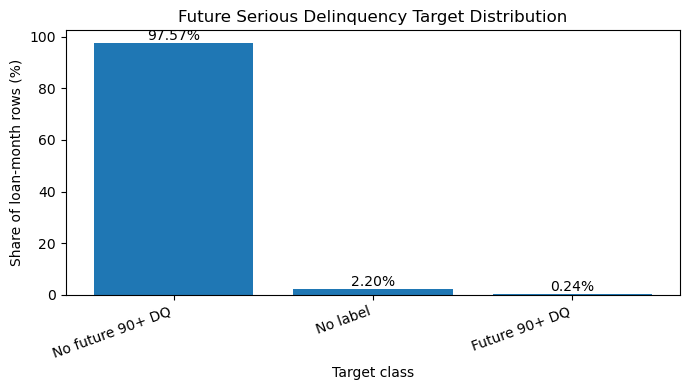

,monthly_reporting_period,rows,target_rate,target_rate_pct,target_rate_3mo_avg
47,2024-12-01,224883,0.0028,0.2824,0.3010
48,2025-01-01,224229,0.0027,0.2725,0.2863
49,2025-02-01,223591,0.0027,0.2737,0.2762
50,2025-03-01,222788,0.0029,0.2922,0.2795
51,2025-04-01,221856,0.0030,0.2984,0.2881
52,2025-05-01,220875,0.0031,0.3079,0.2995
53,2025-06-01,219867,0.0032,0.3175,0.3079
54,2025-07-01,218862,0.0028,0.2778,0.3010
55,2025-08-01,217892,0.0023,0.2304,0.2752
56,2025-09-01,217018,0.0018,0.1774,0.2285


Saved: C:\Users\Esh\OneDrive\Documents\Mortgage Delinquency Forecasting Risk\outputs\2021q1_q2_sample10pct\plots\target_rate_by_reporting_month.png


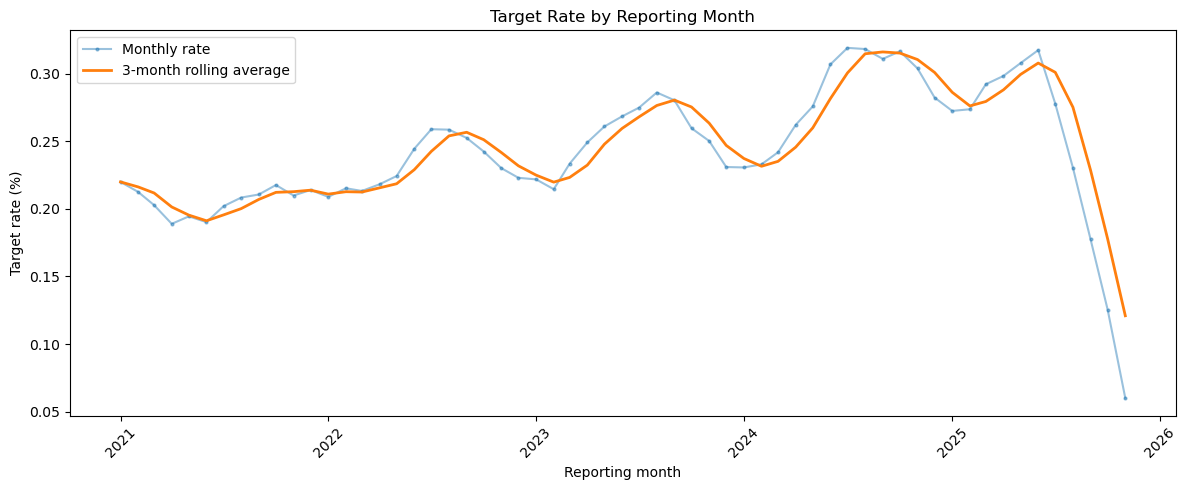

,origination_quarter,rows,target_rate,target_rate_pct
0,2018Q4,3,0.0000,0.0000
1,2019Q1,58,0.0000,0.0000
2,2019Q3,488,0.0000,0.0000
3,2019Q4,1457,0.0000,0.0000
4,2020Q1,2286,0.0009,0.0875
5,2020Q2,4708,0.0013,0.1274
6,2020Q3,31840,0.0031,0.3109
7,2020Q4,2118074,0.0025,0.2470
8,2021Q1,7157757,0.0021,0.2108
9,2021Q2,4293548,0.0029,0.2949


Saved: C:\Users\Esh\OneDrive\Documents\Mortgage Delinquency Forecasting Risk\outputs\2021q1_q2_sample10pct\plots\target_rate_by_origination_quarter.png


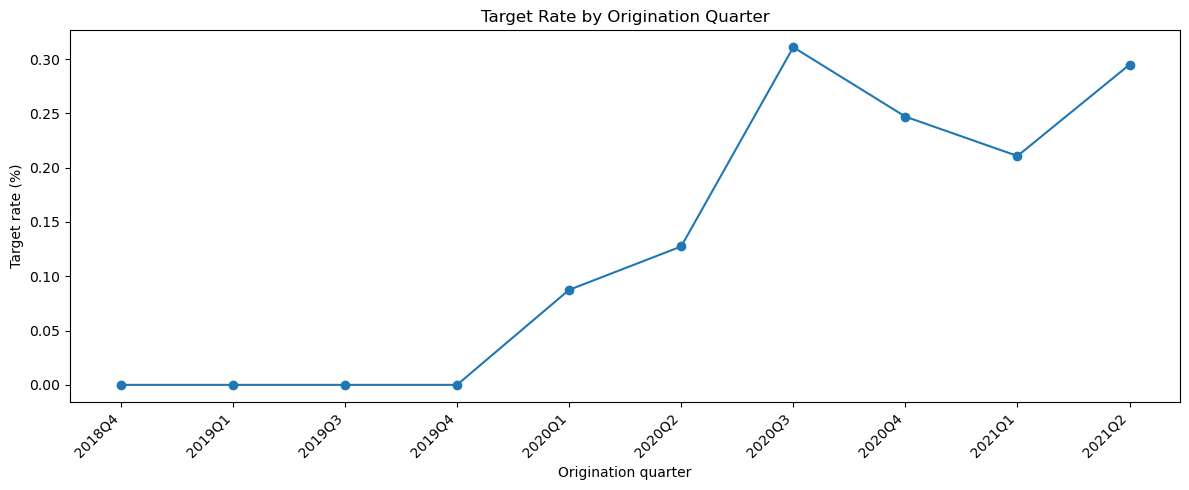

,feature,missing_pct
0,reference_pool_id,100.0000
42,scheduled_principal_current,100.0000
41,repurchase_date,100.0000
9,upb_at_issuance,100.0000
44,unscheduled_principal_current,100.0000
47,disposition_date,99.9994
45,last_paid_installment_date,99.9992
46,foreclosure_date,99.9992
40,upb_at_time_of_removal,99.5860
39,zero_balance_effective_date,99.5860


Saved: C:\Users\Esh\OneDrive\Documents\Mortgage Delinquency Forecasting Risk\outputs\2021q1_q2_sample10pct\plots\missingness_top30.png


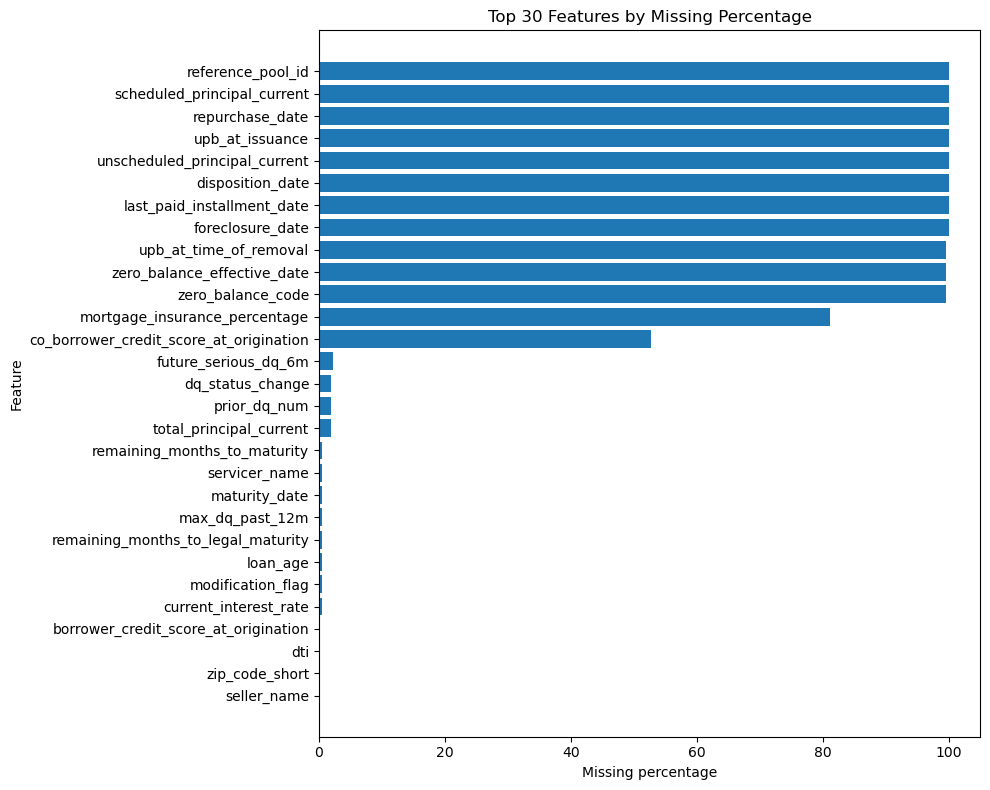

In [4]:
# These are the first plots I checked to understand the target and missingness.
target_plot = target_counts.copy()

def target_label(value):
    if pd.isna(value):
        return "No label"
    if int(value) == 1:
        return "Future 90+ DQ"
    return "No future 90+ DQ"

target_plot["target_label"] = target_plot[TARGET].map(target_label)

display(target_plot)

plt.figure(figsize=(7, 4))
plt.bar(target_plot["target_label"], target_plot["pct"])
plt.title("Future Serious Delinquency Target Distribution")
plt.xlabel("Target class")
plt.ylabel("Share of loan-month rows (%)")
plt.xticks(rotation=20, ha="right")

for i, value in enumerate(target_plot["pct"]):
    plt.text(i, value, f"{value:.2f}%", ha="center", va="bottom")

save_fig("target_distribution.png")
plt.show()

if "monthly_reporting_period" in labeled.columns:
    target_rate_by_month = (
        labeled
        .groupby("monthly_reporting_period")
        .agg(
            rows=(TARGET, "size"),
            target_rate=(TARGET, "mean")
        )
        .reset_index()
    )

    target_rate_by_month["target_rate_pct"] = target_rate_by_month["target_rate"] * 100
    target_rate_by_month["target_rate_3mo_avg"] = (
        target_rate_by_month["target_rate_pct"]
        .rolling(window=3, min_periods=1)
        .mean()
    )

    display(target_rate_by_month.tail(12))

    plt.figure(figsize=(12, 5))
    plt.plot(
        target_rate_by_month["monthly_reporting_period"],
        target_rate_by_month["target_rate_pct"],
        marker="o",
        markersize=2,
        alpha=0.45,
        label="Monthly rate"
    )
    plt.plot(
        target_rate_by_month["monthly_reporting_period"],
        target_rate_by_month["target_rate_3mo_avg"],
        linewidth=2,
        label="3-month rolling average"
    )
    plt.title("Target Rate by Reporting Month")
    plt.xlabel("Reporting month")
    plt.ylabel("Target rate (%)")
    plt.xticks(rotation=45)
    plt.legend()
    save_fig("target_rate_by_reporting_month.png")
    plt.show()

if "origination_quarter" in labeled.columns:
    target_rate_by_origination_quarter = (
        labeled
        .dropna(subset=["origination_quarter"])
        .groupby("origination_quarter")
        .agg(
            rows=(TARGET, "size"),
            target_rate=(TARGET, "mean")
        )
        .reset_index()
    )

    target_rate_by_origination_quarter["target_rate_pct"] = target_rate_by_origination_quarter["target_rate"] * 100

    display(target_rate_by_origination_quarter.tail(12))

    if has_target_rate_spread(target_rate_by_origination_quarter):
        plt.figure(figsize=(12, 5))
        plt.plot(
            range(len(target_rate_by_origination_quarter)),
            target_rate_by_origination_quarter["target_rate_pct"],
            marker="o"
        )
        plt.title("Target Rate by Origination Quarter")
        plt.xlabel("Origination quarter")
        plt.ylabel("Target rate (%)")

        tick_positions = np.linspace(0, len(target_rate_by_origination_quarter) - 1, min(12, len(target_rate_by_origination_quarter))).astype(int)
        plt.xticks(
            tick_positions,
            target_rate_by_origination_quarter.iloc[tick_positions]["origination_quarter"].astype(str),
            rotation=45,
            ha="right"
        )

        save_fig("target_rate_by_origination_quarter.png")
        plt.show()
    else:
        print("Skipping origination-quarter plot because the target rate is too flat to make a useful graph.")

missingness = (
    panel.isna()
    .mean()
    .mul(100)
    .rename("missing_pct")
    .reset_index()
    .rename(columns={"index": "feature"})
    .sort_values("missing_pct", ascending=False)
)

display(missingness.head(30))

top_missing = missingness[missingness["missing_pct"] > 0].head(30).sort_values("missing_pct")

if top_missing.empty:
    print("No missingness plot needed because the top fields have no missing values.")
else:
    plt.figure(figsize=(10, 8))
    plt.barh(top_missing["feature"], top_missing["missing_pct"])
    plt.title("Top 30 Features by Missing Percentage")
    plt.xlabel("Missing percentage")
    plt.ylabel("Feature")
    save_fig("missingness_top30.png")
    plt.show()

## 3. Feature profile

This table is my main pass through all of the columns. For each feature I looked at the data type, missing rate, number of unique values, common values, target rate when the field is missing, and target rate when it is present.

I used this table to catch a few different issues:

- columns that are mostly missing,
- columns with no useful variation,
- high-cardinality fields that would need careful encoding,
- fields where missingness itself may be informative,
- fields that look stable enough to test in a first model.


In [5]:
feature_profile_rows = []

for feature in panel.columns:
    series = panel[feature]
    missing_mask = series.isna()

    if feature == TARGET:
        analysis_method = "target"
    elif is_identifier_feature(feature):
        analysis_method = "identifier_review"
    elif is_unmapped_field(feature):
        analysis_method = "exclude_until_mapped"
    elif is_leakage_like_feature(feature):
        analysis_method = "leakage_review"
    elif pd.api.types.is_numeric_dtype(series):
        analysis_method = "numeric_association"
    else:
        analysis_method = "categorical_or_date_association"

    feature_profile_rows.append({
        "feature": feature,
        "semantic_type": infer_semantic_type(series),
        "dtype": str(series.dtype),
        "missing_pct_actual": missing_mask.mean() * 100,
        "n_unique_actual": series.nunique(dropna=True),
        "target_rate_when_missing": panel.loc[missing_mask, TARGET].mean() if missing_mask.any() else np.nan,
        "target_rate_when_present": panel.loc[~missing_mask, TARGET].mean() if (~missing_mask).any() else np.nan,
        "analysis_method": analysis_method,
        "top_values": top_values_as_text(series)
    })

feature_profile = pd.DataFrame(feature_profile_rows)

profile_cols = [
    "feature", "semantic_type", "dtype", "missing_pct_actual", "n_unique_actual",
    "target_rate_when_missing", "target_rate_when_present", "analysis_method", "top_values"
]

# This is the all-feature screening table.
display(feature_profile[profile_cols].sort_values(["semantic_type", "feature"]).reset_index(drop=True))

feature_profile.to_csv(TABLES / "feature_profile.csv", index=False)

,feature,semantic_type,dtype,missing_pct_actual,n_unique_actual,target_rate_when_missing,target_rate_when_present,analysis_method,top_values
0,amortization_type,categorical,category,0.0000,1,NaN,0.0024,categorical_or_date_association,FRM: 13915701
1,channel,categorical,category,0.0000,3,NaN,0.0024,categorical_or_date_association,R: 9122738; C: 2746440; B: 2046523
2,current_loan_delinquency_status,categorical,category,0.0000,43,NaN,0.0024,categorical_or_date_association,00: 13793673; 01: 73346; 02: 15360; 03: 7158; ...
3,first_time_home_buyer_indicator,categorical,category,0.0000,2,NaN,0.0024,categorical_or_date_association,N: 12045071; Y: 1870630
4,interest_only_loan_indicator,categorical,category,0.0000,1,NaN,0.0024,categorical_or_date_association,N: 13915701
...,...,...,...,...,...,...,...,...,...
63,repurchase_date,possible_leakage_or_post_event,datetime64[ns],100.0000,0,0.0024,NaN,leakage_review,<NA>: 13915701
64,upb_at_time_of_removal,possible_leakage_or_post_event,float32,99.5860,51212,0.0024,NaN,leakage_review,<NA>: 13858088; 199000.0: 39; 174000.0: 33; 14...
65,zero_balance_code,possible_leakage_or_post_event,category,99.5860,7,0.0024,NaN,leakage_review,<NA>: 13858088; 01: 57133; 06: 345; 02: 46; 09...
66,zero_balance_effective_date,possible_leakage_or_post_event,datetime64[ns],99.5860,59,0.0024,NaN,leakage_review,<NA>: 13858088; 2021-12-01: 2177; 2021-10-01: ...


## 4. Numeric relationships with the target

For numeric features, I started with Pearson correlation against the binary target. Since the target is 0/1, this works like a point-biserial correlation and gives a quick read on linear relationship strength.

I also checked Spearman correlation on a sample. I included Spearman because mortgage-risk variables do not always move linearly with risk, but they can still have a ranked or monotonic pattern.


,feature,semantic_type,pearson_r,pearson_abs_r,pearson_p_value,pearson_n,spearman_rho_sample,spearman_abs_rho_sample,spearman_p_value_sample,missing_pct,n_unique
0,current_dq_num,low_cardinality_numeric,0.3929,0.3929,0.0000,13610219,0.3156,0.3156,0.0000,0.0000,3
1,is_60plus_dq,low_cardinality_numeric,0.3749,0.3749,0.0000,13610219,0.3855,0.3855,0.0000,0.0000,2
2,is_30plus_dq,low_cardinality_numeric,0.3280,0.3280,0.0000,13610219,0.3149,0.3149,0.0000,0.0000,2
3,is_current,low_cardinality_numeric,-0.3280,0.3280,0.0000,13610219,-0.3149,0.3149,0.0000,0.0000,2
4,dq_status_worsened,low_cardinality_numeric,0.2755,0.2755,0.0000,13610219,0.2657,0.2657,0.0000,0.0000,2
5,count_30plus_dq_past_12m,low_cardinality_numeric,0.2726,0.2726,0.0000,13610219,0.1908,0.1908,0.0000,0.0000,13
6,count_60plus_dq_past_12m,low_cardinality_numeric,0.2287,0.2287,0.0000,13610219,0.2791,0.2791,0.0000,0.0000,13
7,max_dq_past_12m,numeric,0.2084,0.2084,0.0000,13610219,0.1905,0.1905,0.0000,0.0000,34
8,prior_dq_num,numeric,0.1871,0.1871,0.0000,13337229,0.2645,0.2645,0.0000,2.0058,34
9,borrower_credit_score_at_origination,numeric,-0.0596,0.0596,0.0000,13605254,-0.0501,0.0501,0.0000,0.0365,216


Saved: C:\Users\Esh\OneDrive\Documents\Mortgage Delinquency Forecasting Risk\outputs\2021q1_q2_sample10pct\plots\numeric_pearson_top25.png


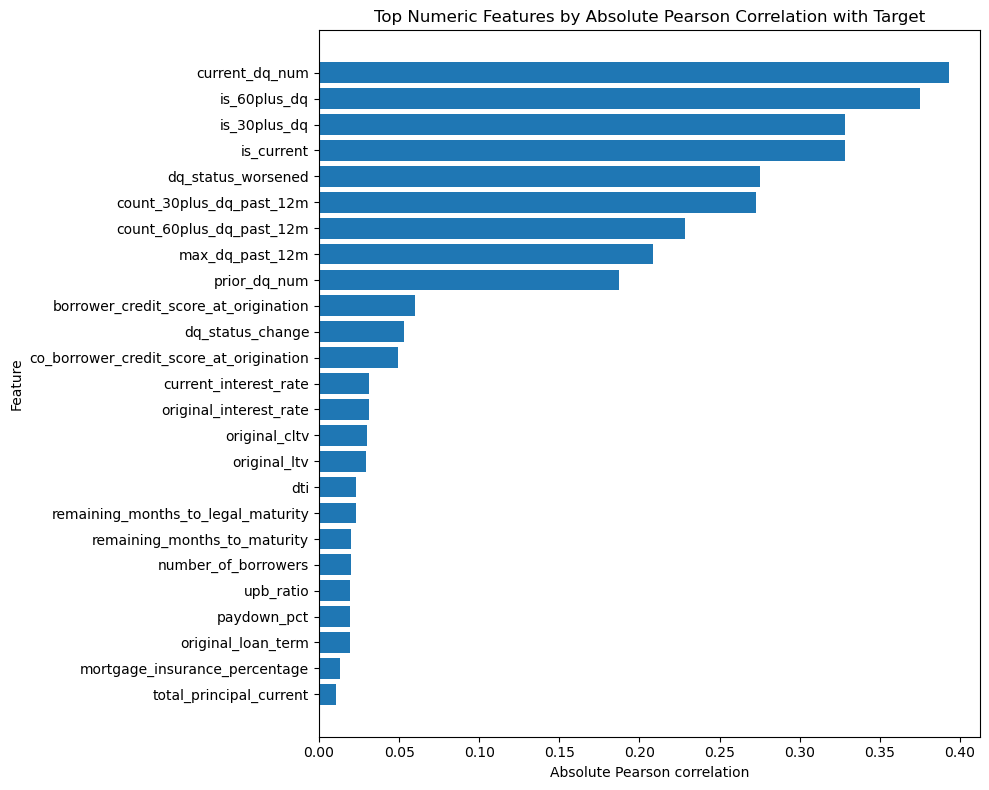

In [6]:
analysis_sample = make_sample(labeled, MAX_ANALYSIS_ROWS, RANDOM_STATE)

numeric_features = [
    col for col in labeled.columns
    if is_main_feature_candidate(col)
    and pd.api.types.is_numeric_dtype(labeled[col])
    and should_plot_feature(labeled, col)
]

numeric_assoc_rows = []

for feature in numeric_features:
    temp_full = labeled[[feature, TARGET]].replace([np.inf, -np.inf], np.nan).dropna()

    if len(temp_full) < MIN_PLOT_ROWS or temp_full[feature].nunique() < 2:
        continue

    if stats is not None:
        try:
            pearson_r, pearson_p = stats.pearsonr(temp_full[feature], temp_full[TARGET])
        except Exception:
            pearson_r, pearson_p = np.nan, np.nan

        temp_sample = analysis_sample[[feature, TARGET]].replace([np.inf, -np.inf], np.nan).dropna()

        try:
            spearman_rho, spearman_p = stats.spearmanr(temp_sample[feature], temp_sample[TARGET])
        except Exception:
            spearman_rho, spearman_p = np.nan, np.nan
    else:
        pearson_r = temp_full[feature].corr(temp_full[TARGET])
        pearson_p = np.nan
        spearman_rho = np.nan
        spearman_p = np.nan
        temp_sample = temp_full

    numeric_assoc_rows.append({
        "feature": feature,
        "semantic_type": infer_semantic_type(labeled[feature]),
        "pearson_r": pearson_r,
        "pearson_abs_r": abs(pearson_r) if pd.notna(pearson_r) else np.nan,
        "pearson_p_value": pearson_p,
        "pearson_n": len(temp_full),
        "spearman_rho_sample": spearman_rho,
        "spearman_abs_rho_sample": abs(spearman_rho) if pd.notna(spearman_rho) else np.nan,
        "spearman_p_value_sample": spearman_p,
        "missing_pct": labeled[feature].isna().mean() * 100,
        "n_unique": labeled[feature].nunique(dropna=True)
    })

numeric_assoc = (
    pd.DataFrame(numeric_assoc_rows)
    .sort_values("pearson_abs_r", ascending=False)
    .reset_index(drop=True)
)

if numeric_assoc.empty:
    numeric_assoc = pd.DataFrame(columns=[
        "feature", "semantic_type", "pearson_r", "pearson_abs_r", "pearson_p_value", "pearson_n",
        "spearman_rho_sample", "spearman_abs_rho_sample", "spearman_p_value_sample",
        "missing_pct", "n_unique"
    ])

num_cols = [
    "feature", "semantic_type", "pearson_r", "pearson_abs_r", "pearson_p_value", "pearson_n",
    "spearman_rho_sample", "spearman_abs_rho_sample", "spearman_p_value_sample",
    "missing_pct", "n_unique"
]
display(numeric_assoc[num_cols].head(25))

top_numeric = (
    numeric_assoc
    .dropna(subset=["pearson_abs_r"])
    .query("pearson_abs_r > 0")
    .head(25)
    .sort_values("pearson_abs_r")
)

if top_numeric.empty:
    print("Skipping numeric association plot because no numeric associations were available.")
else:
    plt.figure(figsize=(10, 8))
    plt.barh(top_numeric["feature"], top_numeric["pearson_abs_r"])
    plt.title("Top Numeric Features by Absolute Pearson Correlation with Target")
    plt.xlabel("Absolute Pearson correlation")
    plt.ylabel("Feature")
    save_fig("numeric_pearson_top25.png")
    plt.show()

numeric_assoc.to_csv(TABLES / "numeric_assoc.csv", index=False)

,current_dq_num,is_60plus_dq,is_30plus_dq,is_current,dq_status_worsened,count_30plus_dq_past_12m,count_60plus_dq_past_12m,max_dq_past_12m,prior_dq_num,borrower_credit_score_at_origination,dq_status_change,co_borrower_credit_score_at_origination,current_interest_rate,original_interest_rate,original_cltv,future_serious_dq_6m
current_dq_num,1.0000,0.6675,0.9523,-0.9523,0.7746,0.5302,0.2697,0.2845,0.3074,-0.0811,0.2920,-0.0755,0.0412,0.0412,0.0267,0.3743
is_60plus_dq,0.6675,1.0000,0.4084,-0.4084,0.3389,0.3280,0.2988,0.1829,0.2600,-0.0412,0.1399,-0.0433,0.0229,0.0229,0.0149,0.3557
is_30plus_dq,0.9523,0.4084,1.0000,-1.0000,0.8106,0.5155,0.2082,0.2739,0.2703,-0.0826,0.3006,-0.0748,0.0411,0.0411,0.0266,0.3130
is_current,-0.9523,-0.4084,-1.0000,1.0000,-0.8106,-0.5155,-0.2082,-0.2739,-0.2703,0.0826,-0.3006,0.0748,-0.0411,-0.0411,-0.0266,-0.3130
dq_status_worsened,0.7746,0.3389,0.8106,-0.8106,1.0000,0.2671,0.1045,0.2068,0.0614,-0.0560,0.4038,-0.0519,0.0257,0.0257,0.0182,0.2652
count_30plus_dq_past_12m,0.5302,0.3280,0.5155,-0.5155,0.2671,1.0000,0.6968,0.6948,0.4986,-0.1249,-0.1825,-0.1128,0.0626,0.0628,0.0403,0.2517
count_60plus_dq_past_12m,0.2697,0.2988,0.2082,-0.2082,0.1045,0.6968,1.0000,0.7559,0.4889,-0.0683,-0.3293,-0.0636,0.0393,0.0395,0.0297,0.1900
max_dq_past_12m,0.2845,0.1829,0.2739,-0.2739,0.2068,0.6948,0.7559,1.0000,0.4073,-0.0938,-0.2384,-0.0829,0.0510,0.0514,0.0363,0.1716
prior_dq_num,0.3074,0.2600,0.2703,-0.2703,0.0614,0.4986,0.4889,0.4073,1.0000,-0.0581,-0.8203,-0.0538,0.0324,0.0324,0.0210,0.1455
borrower_credit_score_at_origination,-0.0811,-0.0412,-0.0826,0.0826,-0.0560,-0.1249,-0.0683,-0.0938,-0.0581,1.0000,0.0097,0.6532,-0.2982,-0.2982,-0.2413,-0.0548


Saved: C:\Users\Esh\OneDrive\Documents\Mortgage Delinquency Forecasting Risk\outputs\2021q1_q2_sample10pct\plots\pearson_correlation_heatmap.png


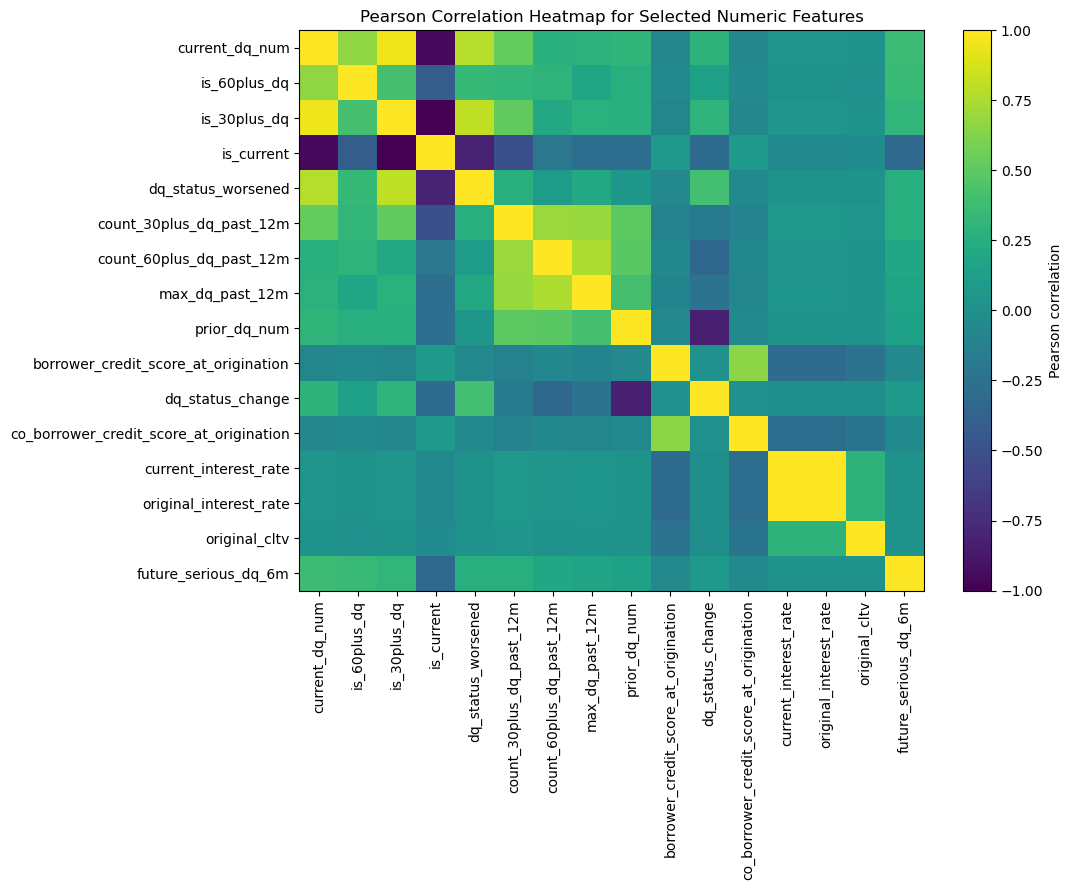

In [7]:
# Building a focused Pearson correlation heatmap
# I am using the strongest numeric candidates instead of every numeric column so the heatmap stays readable.

corr_features = (
    numeric_assoc
    .dropna(subset=["pearson_abs_r"])
    .head(15)["feature"]
    .tolist()
)

if TARGET not in corr_features:
    corr_features.append(TARGET)

corr_features = [
    feature for feature in corr_features
    if feature in labeled.columns
    and pd.api.types.is_numeric_dtype(labeled[feature])
]

corr_data = labeled[corr_features].replace([np.inf, -np.inf], np.nan).dropna()

if len(corr_data) > MAX_ANALYSIS_ROWS:
    corr_data = corr_data.sample(MAX_ANALYSIS_ROWS, random_state=RANDOM_STATE)

if len(corr_features) >= 2 and len(corr_data) >= MIN_PLOT_ROWS:
    corr_matrix = corr_data.corr(method="pearson")

    display(corr_matrix)

    plt.figure(figsize=(11, 9))
    plt.imshow(corr_matrix, aspect="auto")
    plt.colorbar(label="Pearson correlation")
    plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
    plt.yticks(range(len(corr_matrix.index)), corr_matrix.index)
    plt.title("Pearson Correlation Heatmap for Selected Numeric Features")
    save_fig("pearson_correlation_heatmap.png")
    plt.show()
else:
    print("Skipping correlation heatmap because there are not enough numeric features.")

## 5. Categorical relationships with the target

For categorical fields, I used Cramer's V and chi-square tests when the number of categories was manageable. This helped me compare categorical predictors without relying only on visual inspection.

I still reviewed high-cardinality fields, but I would not directly one-hot encode fields like raw history strings, ZIP codes, seller names, or servicer names without grouping or regularization.


,feature,semantic_type,n_unique_full,n_unique_sample,missing_pct,cramers_v_sample,chi_square_p_value_sample,association_computed_on_sample,top_reliable_target_rate_category_sample,top_reliable_category_target_rate_sample,top_reliable_category_lift_vs_base_sample
0,current_loan_delinquency_status,categorical,3,3,0.0000,0.4204,0.0000,True,02,0.5680,223.6328
1,zip_code_short,categorical,884,496,0.0003,0.0501,0.0001,True,292,0.0274,10.7863
2,modification_flag,categorical,2,2,0.0000,0.0478,0.0000,True,Y,0.0775,30.5082
3,msa,categorical,409,254,0.0000,0.0376,0.0000,True,26820,0.0195,7.6695
4,loan_purpose,categorical,3,3,0.0000,0.0275,0.0000,True,P,0.0047,1.8379
5,first_time_home_buyer_indicator,categorical,2,2,0.0000,0.0247,0.0000,True,Y,0.0057,2.2450
6,servicer_name,categorical,44,44,0.0001,0.0225,0.0000,True,NewRez LLC,0.0106,4.1552
7,property_state,categorical,54,53,0.0000,0.0184,0.0026,True,LA,0.0074,2.9194
8,seller_name,categorical,32,32,0.0001,0.0184,0.0000,True,"Broker Solutions, Inc. dba New American Funding",0.0054,2.1298
9,channel,categorical,3,3,0.0000,0.0124,0.0000,True,C,0.0035,1.3650


Saved: C:\Users\Esh\OneDrive\Documents\Mortgage Delinquency Forecasting Risk\outputs\2021q1_q2_sample10pct\plots\categorical_cramersv_top25.png


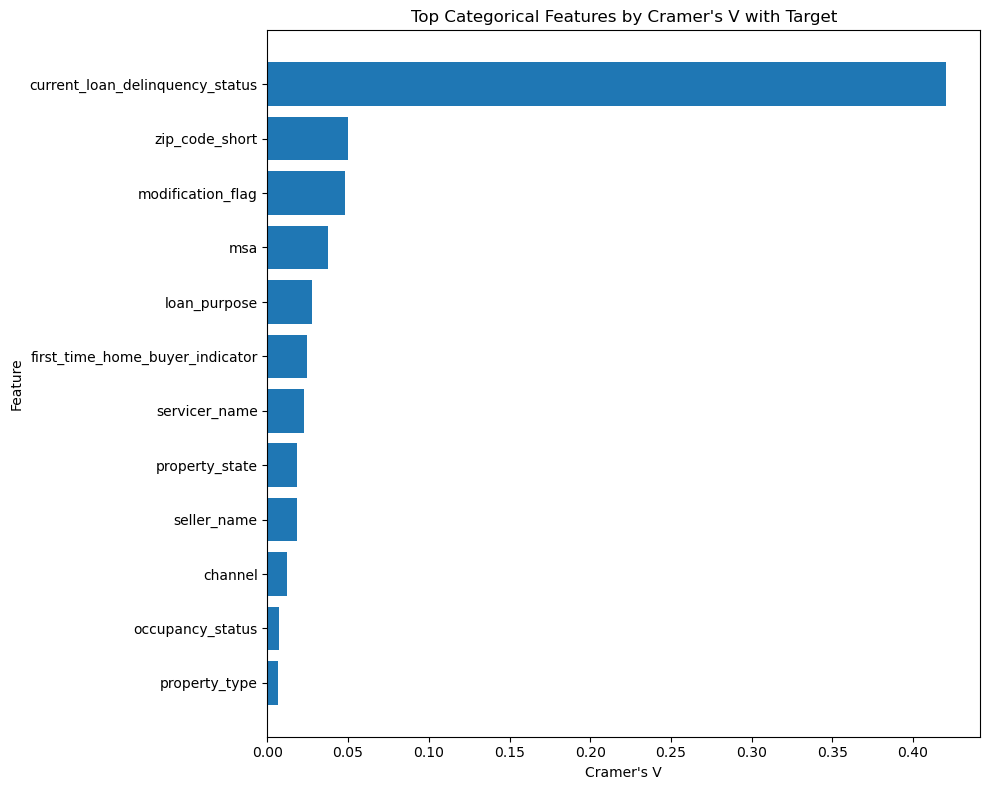

In [8]:
categorical_features = [
    col for col in labeled.columns
    if is_main_feature_candidate(col)
    and not pd.api.types.is_numeric_dtype(labeled[col])
    and labeled[col].nunique(dropna=True) > 1
    and labeled[col].isna().mean() * 100 <= MAX_PLOT_MISSING_PCT
]

categorical_assoc_rows = []

for feature in categorical_features:
    temp = analysis_sample[[feature, TARGET]].dropna().copy()

    if len(temp) < MIN_PLOT_ROWS or temp[feature].nunique() < 2:
        continue

    counts = temp[feature].astype(str).value_counts()
    common_categories = counts[counts >= MIN_CATEGORY_COUNT].index

    if len(common_categories) < 2:
        continue

    temp[feature] = np.where(
        temp[feature].astype(str).isin(common_categories),
        temp[feature].astype(str),
        "Other_Rare"
    )

    confusion = pd.crosstab(temp[feature], temp[TARGET])

    if confusion.shape[0] < 2 or confusion.shape[1] < 2:
        continue

    if stats is not None:
        chi2, p_value, dof, expected = stats.chi2_contingency(confusion)
    else:
        p_value = np.nan

    cv = cramers_v_from_table(confusion)

    rate_table = target_rate_table(temp, feature, TARGET, min_count=MIN_CATEGORY_COUNT)

    if not rate_table.empty:
        top_row = rate_table.sort_values("target_rate", ascending=False).iloc[0]
        top_category = top_row[feature]
        top_rate = top_row["target_rate"]
        top_lift = top_rate / temp[TARGET].mean() if temp[TARGET].mean() > 0 else np.nan
    else:
        top_category = np.nan
        top_rate = np.nan
        top_lift = np.nan

    categorical_assoc_rows.append({
        "feature": feature,
        "semantic_type": infer_semantic_type(labeled[feature]),
        "n_unique_full": labeled[feature].nunique(dropna=True),
        "n_unique_sample": temp[feature].nunique(dropna=True),
        "missing_pct": labeled[feature].isna().mean() * 100,
        "cramers_v_sample": cv,
        "chi_square_p_value_sample": p_value,
        "association_computed_on_sample": True,
        "top_reliable_target_rate_category_sample": top_category,
        "top_reliable_category_target_rate_sample": top_rate,
        "top_reliable_category_lift_vs_base_sample": top_lift
    })

categorical_assoc = (
    pd.DataFrame(categorical_assoc_rows)
    .sort_values("cramers_v_sample", ascending=False)
    .reset_index(drop=True)
)

if categorical_assoc.empty:
    categorical_assoc = pd.DataFrame(columns=[
        "feature", "semantic_type", "n_unique_full", "n_unique_sample", "missing_pct",
        "cramers_v_sample", "chi_square_p_value_sample", "association_computed_on_sample",
        "top_reliable_target_rate_category_sample", "top_reliable_category_target_rate_sample",
        "top_reliable_category_lift_vs_base_sample"
    ])

cat_cols = [
    "feature", "semantic_type", "n_unique_full", "n_unique_sample", "missing_pct",
    "cramers_v_sample", "chi_square_p_value_sample", "association_computed_on_sample",
    "top_reliable_target_rate_category_sample", "top_reliable_category_target_rate_sample",
    "top_reliable_category_lift_vs_base_sample"
]
display(categorical_assoc[cat_cols].head(25))

top_categorical = (
    categorical_assoc
    .dropna(subset=["cramers_v_sample"])
    .query("cramers_v_sample > 0")
    .head(25)
    .sort_values("cramers_v_sample")
)

if top_categorical.empty:
    print("Skipping categorical association plot because no categorical associations were available.")
else:
    plt.figure(figsize=(10, 8))
    plt.barh(top_categorical["feature"], top_categorical["cramers_v_sample"])
    plt.title("Top Categorical Features by Cramer's V with Target")
    plt.xlabel("Cramer's V")
    plt.ylabel("Feature")
    save_fig("categorical_cramersv_top25.png")
    plt.show()

categorical_assoc.to_csv(TABLES / "categorical_assoc.csv", index=False)

## 6. Date fields

For date columns, I converted dates to ordinal values for a quick EDA association check. I would not use the raw date ordinals directly in the model. For modeling, I would turn date fields into safer variables like loan age, months since origination, origination quarter, reporting quarter, or seasoning buckets.


In [9]:
datetime_rows = []

for feature in panel.columns:
    if infer_semantic_type(panel[feature]) != "date_or_time":
        continue

    temp = labeled[[feature, TARGET]].dropna().copy()

    if len(temp) < MIN_PLOT_ROWS:
        continue

    if not pd.api.types.is_datetime64_any_dtype(temp[feature]):
        converted = pd.to_datetime(temp[feature], errors="coerce")
    else:
        converted = temp[feature]

    temp = temp.assign(_date_numeric=converted.map(lambda x: x.toordinal() if pd.notna(x) else np.nan))
    temp = temp.dropna(subset=["_date_numeric"])

    if len(temp) < MIN_PLOT_ROWS or temp["_date_numeric"].nunique() < 2:
        continue

    if stats is not None:
        try:
            pearson_r, pearson_p = stats.pearsonr(temp["_date_numeric"], temp[TARGET])
        except Exception:
            pearson_r, pearson_p = np.nan, np.nan
    else:
        pearson_r = temp["_date_numeric"].corr(temp[TARGET])
        pearson_p = np.nan

    datetime_rows.append({
        "feature": feature,
        "pearson_r": pearson_r,
        "pearson_abs_r": abs(pearson_r) if pd.notna(pearson_r) else np.nan,
        "pearson_p_value": pearson_p,
        "n": len(temp),
        "missing_pct": labeled[feature].isna().mean() * 100,
        "n_unique": labeled[feature].nunique(dropna=True)
    })

datetime_assoc = (
    pd.DataFrame(datetime_rows)
    .sort_values("pearson_abs_r", ascending=False)
    .reset_index(drop=True)
)

display(datetime_assoc.head(20))

datetime_assoc.to_csv(TABLES / "datetime_assoc.csv", index=False)

C:\Users\Esh\AppData\Local\Temp\ipykernel_13456\342592523.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  converted = pd.to_datetime(temp[feature], errors="coerce")


C:\Users\Esh\AppData\Local\Temp\ipykernel_13456\342592523.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  converted = pd.to_datetime(temp[feature], errors="coerce")


,feature,pearson_r,pearson_abs_r,pearson_p_value,n,missing_pct,n_unique
0,maturity_date,0.0243,0.0243,0.0000,13610219,0.0000,310
1,origination_date,0.0051,0.0051,0.0000,13610219,0.0000,26
2,first_payment_date,0.0047,0.0047,0.0000,13610219,0.0000,15
3,origination_quarter,0.0047,0.0047,0.0000,13610219,0.0000,10
4,monthly_reporting_period,0.0035,0.0035,0.0000,13610219,0.0000,59
5,reporting_quarter,0.0034,0.0034,0.0000,13610219,0.0000,20


## 7. Relationship plots

The plots below are the focused plots I used after the table-based pass. I used them to see whether the strongest relationships looked believable or whether they were being driven by a small number of weird values.

The full feature profile is still the all-column check. These plots are the ones I would spend more time interpreting before modeling.


C:\Users\Esh\AppData\Local\Temp\ipykernel_13456\3827481732.py:233: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  temp.groupby(f"{feature}_bin")


Numeric feature: current_dq_num


,current_dq_num_bin,count,target_rate,feature_mean,target_rate_pct
0,"(-0.001, 2.0]",13610219,0.0024,0.0075,0.2431


Skipping plot for current_dq_num: the table is empty or too flat.


C:\Users\Esh\AppData\Local\Temp\ipykernel_13456\3827481732.py:233: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  temp.groupby(f"{feature}_bin")


...

Skipping plot for max_dq_past_12m: the table is empty or too flat.


C:\Users\Esh\AppData\Local\Temp\ipykernel_13456\3827481732.py:233: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  temp.groupby(f"{feature}_bin")


Numeric feature: borrower_credit_score_at_origination


,borrower_credit_score_at_origination_bin,count,target_rate,feature_mean,target_rate_pct
0,"(619.999, 702.0]",1387015,0.0101,676.8420,1.0131
1,"(702.0, 729.0]",1355799,0.0051,716.6318,0.5098
2,"(729.0, 749.0]",1351451,0.0029,740.1425,0.2858
3,"(749.0, 764.0]",1381452,0.0020,757.3068,0.1995
4,"(764.0, 776.0]",1405631,0.0012,770.7143,0.1211
5,"(776.0, 786.0]",1423408,0.0009,781.5724,0.0894
6,"(786.0, 794.0]",1339796,0.0006,790.5210,0.0634
7,"(794.0, 801.0]",1352469,0.0005,798.1608,0.0523
8,"(801.0, 809.0]",1426822,0.0004,805.6127,0.0378
9,"(809.0, 839.0]",1181411,0.0003,814.9219,0.0328


Saved: C:\Users\Esh\OneDrive\Documents\Mortgage Delinquency Forecasting Risk\outputs\2021q1_q2_sample10pct\plots\target_rate_by_binned_borrower_credit_score_at_origination.png


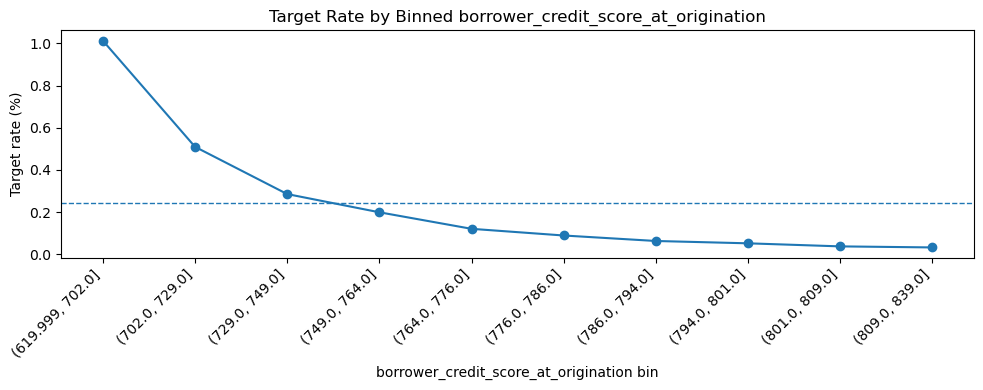

C:\Users\Esh\AppData\Local\Temp\ipykernel_13456\3827481732.py:233: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  temp.groupby(f"{feature}_bin")


Numeric feature: dti


,dti_bin,count,target_rate,feature_mean,target_rate_pct
0,"(0.999, 19.0]",1427535,0.0006,15.5102,0.0560
1,"(19.0, 24.0]",1591207,0.0012,22.1282,0.1190
2,"(24.0, 27.0]",1162939,0.0014,26.0201,0.1403
3,"(27.0, 31.0]",1674348,0.0018,29.5242,0.1829
4,"(31.0, 34.0]",1284085,0.0022,33.0056,0.2237
5,"(34.0, 37.0]",1321531,0.0026,36.0059,0.2567
6,"(37.0, 40.0]",1343935,0.0034,39.0084,0.3353
7,"(40.0, 43.0]",1402184,0.0039,42.0100,0.3907
8,"(43.0, 46.0]",1242522,0.0045,44.8648,0.4513
9,"(46.0, 52.0]",1159550,0.0033,48.4043,0.3308


Saved: C:\Users\Esh\OneDrive\Documents\Mortgage Delinquency Forecasting Risk\outputs\2021q1_q2_sample10pct\plots\target_rate_by_binned_dti.png


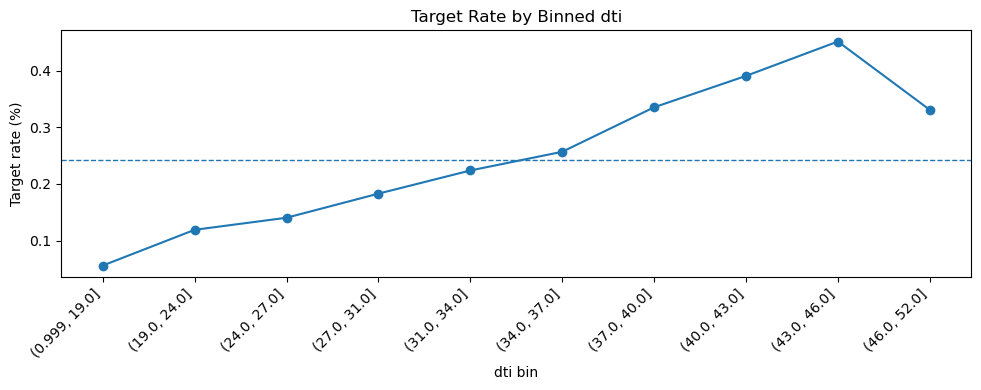

C:\Users\Esh\AppData\Local\Temp\ipykernel_13456\3827481732.py:233: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  temp.groupby(f"{feature}_bin")


Numeric feature: original_ltv


,original_ltv_bin,count,target_rate,feature_mean,target_rate_pct
0,"(3.999, 41.0]",1384375,0.0007,32.2206,0.0742
1,"(41.0, 51.0]",1395946,0.0009,46.8956,0.0941
2,"(51.0, 58.0]",1356842,0.0013,55.1791,0.1269
3,"(58.0, 64.0]",1436490,0.0015,60.9609,0.1451
4,"(64.0, 70.0]",1536412,0.0021,67.9584,0.2102
5,"(70.0, 75.0]",1603622,0.0021,73.7766,0.2082
6,"(75.0, 80.0]",2349382,0.0028,79.3133,0.2776
7,"(80.0, 92.0]",1206879,0.0039,87.5415,0.3884
8,"(92.0, 97.0]",1340271,0.0068,95.4198,0.6836


Saved: C:\Users\Esh\OneDrive\Documents\Mortgage Delinquency Forecasting Risk\outputs\2021q1_q2_sample10pct\plots\target_rate_by_binned_original_ltv.png


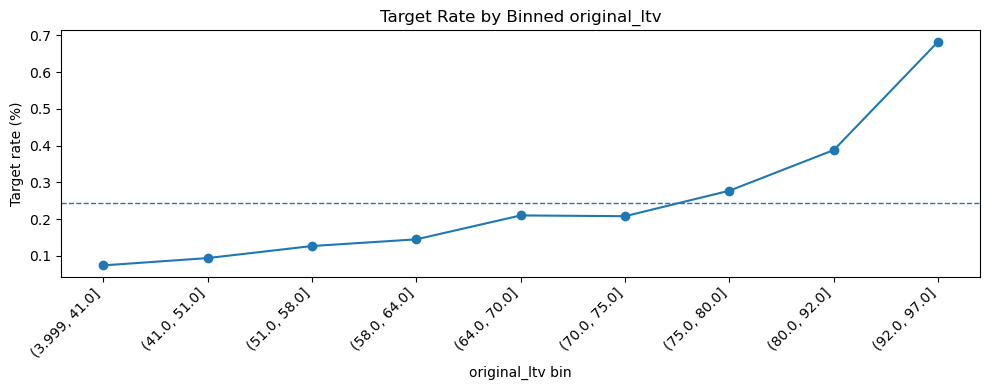

C:\Users\Esh\AppData\Local\Temp\ipykernel_13456\3827481732.py:233: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  temp.groupby(f"{feature}_bin")


Numeric feature: original_cltv


,original_cltv_bin,count,target_rate,feature_mean,target_rate_pct
0,"(3.999, 42.0]",1459461,0.0007,32.9528,0.0747
1,"(42.0, 51.0]",1272048,0.0010,47.3079,0.0954
2,"(51.0, 59.0]",1617086,0.0012,55.8378,0.1162
3,"(59.0, 64.0]",1143607,0.0015,61.4551,0.1475
4,"(64.0, 70.0]",1537005,0.0021,67.9524,0.2078
5,"(70.0, 75.0]",1599683,0.0021,73.7760,0.2074
6,"(75.0, 80.0]",2369537,0.0027,79.3019,0.2727
7,"(80.0, 92.0]",1255502,0.0039,87.5190,0.3889
8,"(92.0, 113.0]",1356290,0.0069,95.6290,0.6903


Saved: C:\Users\Esh\OneDrive\Documents\Mortgage Delinquency Forecasting Risk\outputs\2021q1_q2_sample10pct\plots\target_rate_by_binned_original_cltv.png


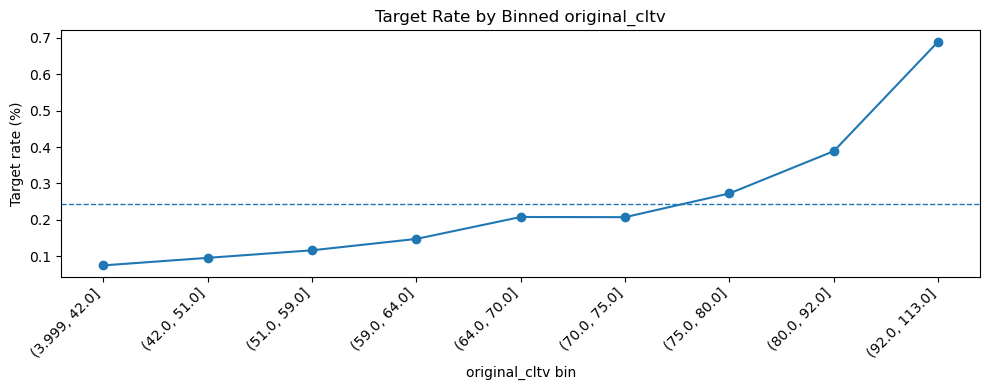

C:\Users\Esh\AppData\Local\Temp\ipykernel_13456\3827481732.py:204: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  temp.groupby(feature, dropna=False)


Categorical feature: channel


,channel,count,target_rate,pct_of_rows,target_rate_pct
1,C,2683993,0.0032,0.1972,0.3220
0,B,2000426,0.0029,0.1470,0.2915
2,R,8925800,0.0021,0.6558,0.2085


Saved: C:\Users\Esh\OneDrive\Documents\Mortgage Delinquency Forecasting Risk\outputs\2021q1_q2_sample10pct\plots\target_rate_by_channel.png


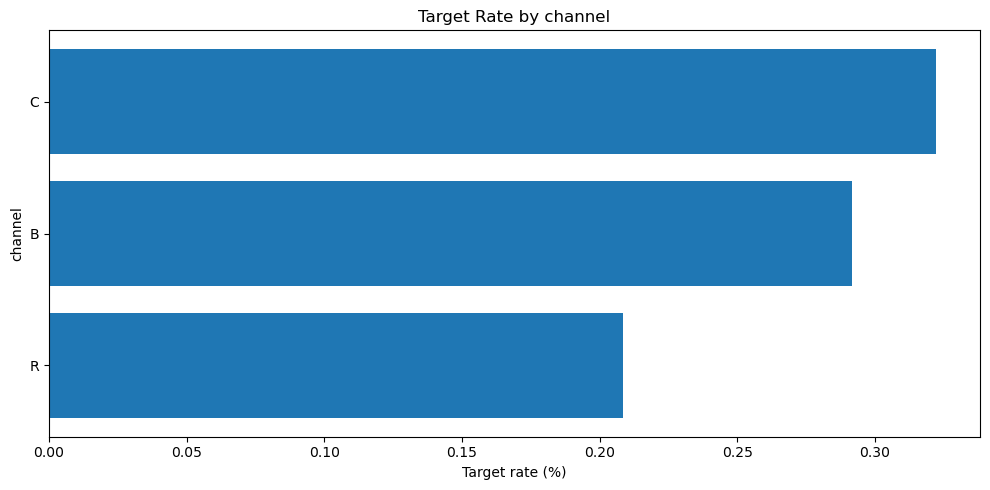

Categorical feature: first_time_home_buyer_indicator


C:\Users\Esh\AppData\Local\Temp\ipykernel_13456\3827481732.py:204: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  temp.groupby(feature, dropna=False)


,first_time_home_buyer_indicator,count,target_rate,pct_of_rows,target_rate_pct
1,Y,1824517,0.0055,0.1341,0.5481
0,N,11785702,0.0020,0.8659,0.1959


Saved: C:\Users\Esh\OneDrive\Documents\Mortgage Delinquency Forecasting Risk\outputs\2021q1_q2_sample10pct\plots\target_rate_by_first_time_home_buyer_indicator.png


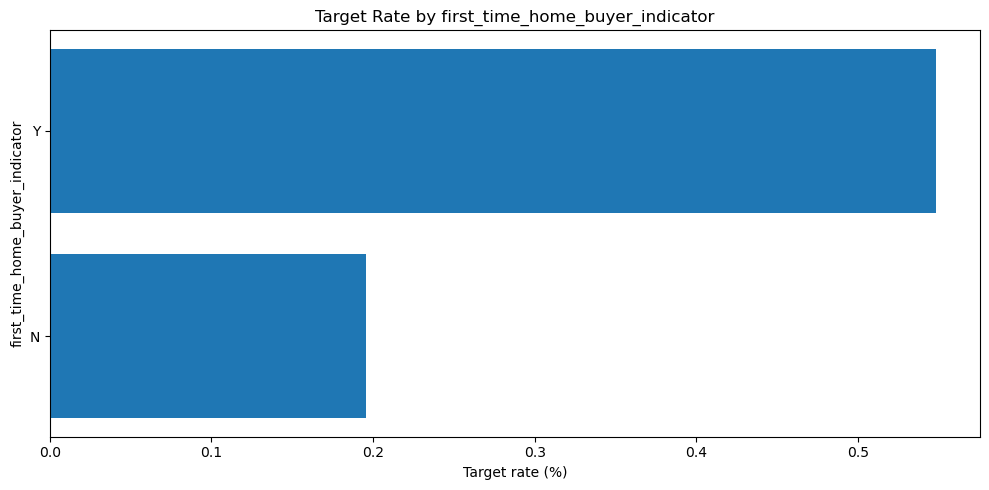

C:\Users\Esh\AppData\Local\Temp\ipykernel_13456\3827481732.py:204: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  temp.groupby(feature, dropna=False)


Categorical feature: loan_purpose


,loan_purpose,count,target_rate,pct_of_rows,target_rate_pct
1,P,3754577,0.0044,0.2759,0.4351
0,C,2933878,0.0022,0.2156,0.2244
2,R,6921764,0.0015,0.5086,0.1469


Saved: C:\Users\Esh\OneDrive\Documents\Mortgage Delinquency Forecasting Risk\outputs\2021q1_q2_sample10pct\plots\target_rate_by_loan_purpose.png


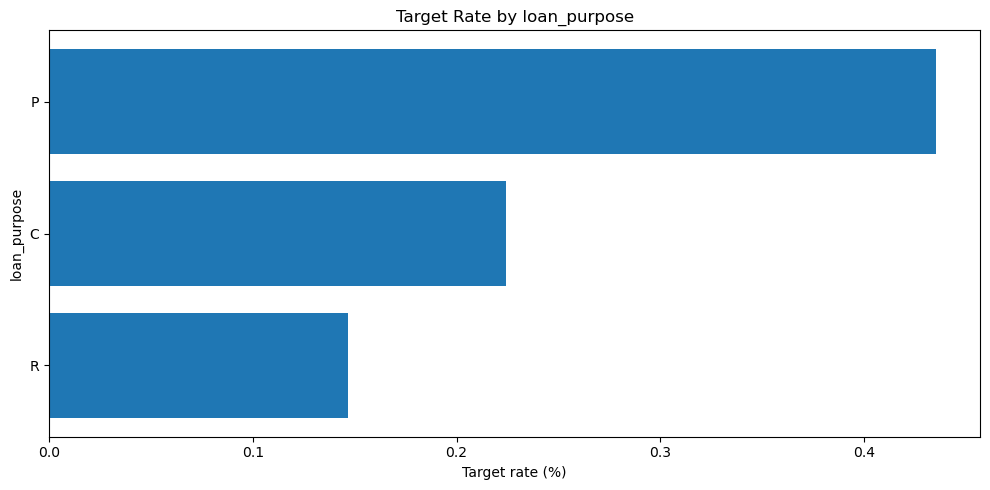

C:\Users\Esh\AppData\Local\Temp\ipykernel_13456\3827481732.py:204: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  temp.groupby(feature, dropna=False)


Categorical feature: property_type


,property_type,count,target_rate,pct_of_rows,target_rate_pct
2,MH,96023,0.0042,0.0071,0.4186
4,SF,8629844,0.0025,0.6341,0.2526
3,PU,3597858,0.0023,0.2643,0.2269
0,CO,1243041,0.0021,0.0913,0.2145
1,CP,43453,0.0012,0.0032,0.1243


Saved: C:\Users\Esh\OneDrive\Documents\Mortgage Delinquency Forecasting Risk\outputs\2021q1_q2_sample10pct\plots\target_rate_by_property_type.png


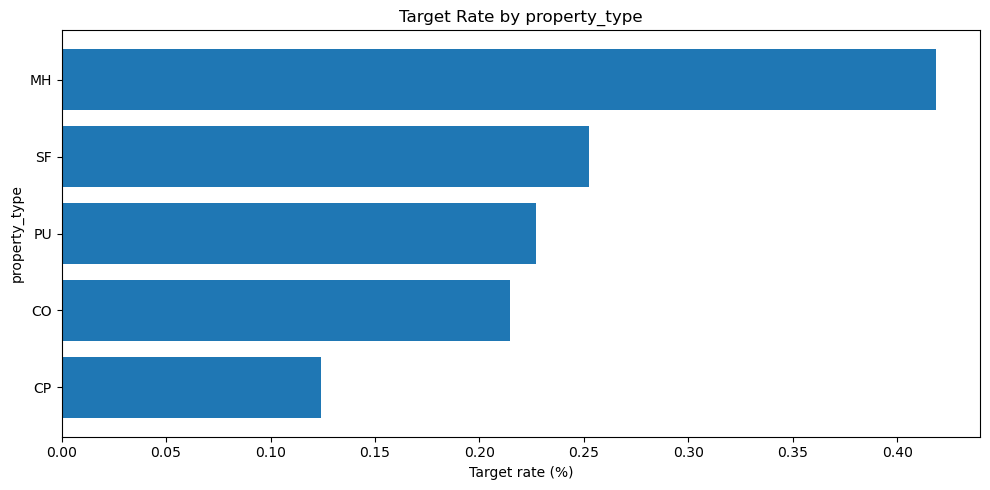

Categorical feature: occupancy_status


C:\Users\Esh\AppData\Local\Temp\ipykernel_13456\3827481732.py:204: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  temp.groupby(feature, dropna=False)


,occupancy_status,count,target_rate,pct_of_rows,target_rate_pct
1,P,12368440,0.0026,0.9088,0.2552
2,S,446634,0.0013,0.0328,0.1312
0,I,795145,0.0012,0.0584,0.1172


Saved:

 C:\Users\Esh\OneDrive\Documents\Mortgage Delinquency Forecasting Risk\outputs\2021q1_q2_sample10pct\plots\target_rate_by_occupancy_status.png


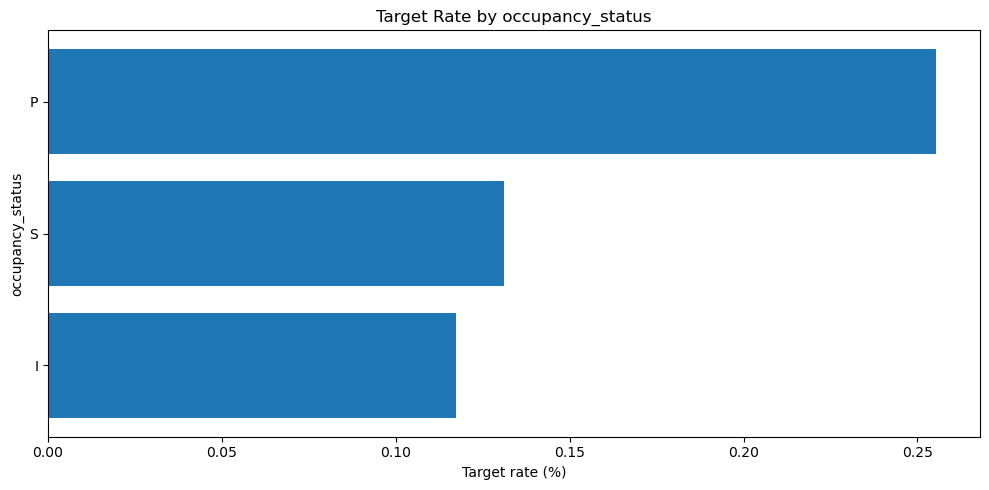

C:\Users\Esh\AppData\Local\Temp\ipykernel_13456\3827481732.py:204: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  temp.groupby(feature, dropna=False)


Categorical feature: property_state


,property_state,count,target_rate,pct_of_rows,target_rate_pct
19,LA,102289,0.0052,0.0075,0.5211
43,SD,37680,0.0039,0.0028,0.3928
9,FL,838569,0.0039,0.0616,0.3860
26,MS,54130,0.0033,0.0040,0.3344
45,TX,899507,0.0032,0.0661,0.3163
14,ID,127600,0.0030,0.0094,0.3033
37,OK,79243,0.0030,0.0058,0.2991
15,IL,484729,0.0030,0.0356,0.2969
46,UT,247525,0.0029,0.0182,0.2945
10,GA,403306,0.0028,0.0296,0.2842


Skipping plot for property_state: high-cardinality field is clearer as a table.


Categorical feature: modification_flag


C:\Users\Esh\AppData\Local\Temp\ipykernel_13456\3827481732.py:204: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  temp.groupby(feature, dropna=False)


,modification_flag,count,target_rate,pct_of_rows,target_rate_pct
1,Y,15223,0.1111,0.0011,11.1148
0,N,13594996,0.0023,0.9989,0.2309


Saved: C:\Users\Esh\OneDrive\Documents\Mortgage Delinquency Forecasting Risk\outputs\2021q1_q2_sample10pct\plots\target_rate_by_modification_flag.png


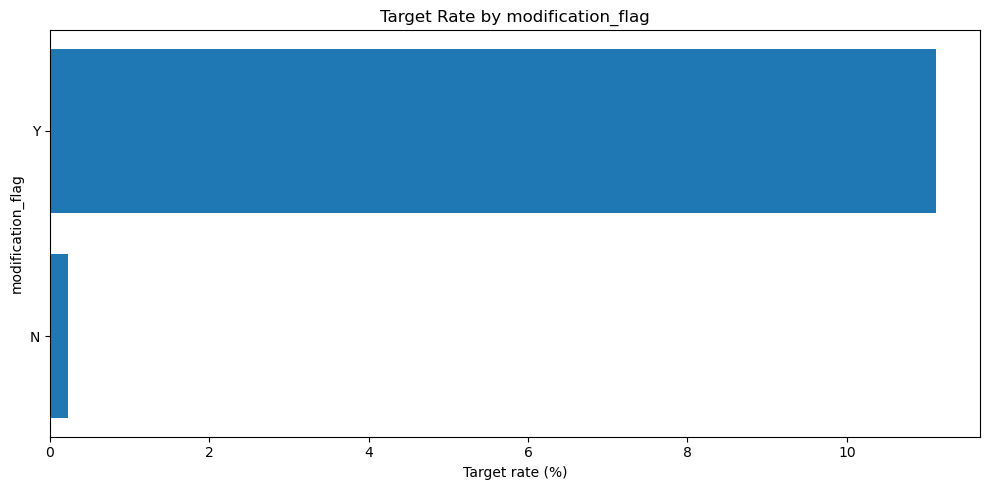

Categorical feature: current_loan_delinquency_status


C:\Users\Esh\AppData\Local\Temp\ipykernel_13456\3827481732.py:204: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  temp.groupby(feature, dropna=False)


,current_loan_delinquency_status,count,target_rate,pct_of_rows,target_rate_pct
2,02,14941,0.5593,0.0011,55.9333
1,01,71810,0.1302,0.0053,13.0205
0,00,13523468,0.0011,0.9936,0.1137


Saved: C:\Users\Esh\OneDrive\Documents\Mortgage Delinquency Forecasting Risk\outputs\2021q1_q2_sample10pct\plots\target_rate_by_current_loan_delinquency_status.png


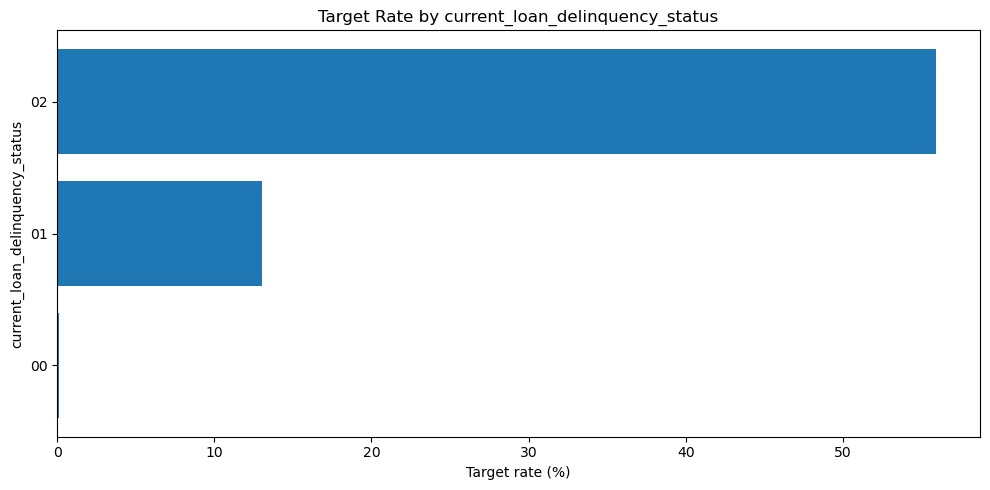

In [10]:
focused_numeric = [
    "current_dq_num",
    "prior_dq_num",
    "dq_status_worsened",
    "count_30plus_dq_past_12m",
    "count_60plus_dq_past_12m",
    "max_dq_past_12m",
    "borrower_credit_score_at_origination",
    "dti",
    "original_ltv",
    "original_cltv",
    "original_interest_rate",
    "upb_ratio",
    "paydown_pct",
    "loan_age"
]

for feature in numeric_assoc.head(10)["feature"].tolist():
    if feature not in focused_numeric:
        focused_numeric.append(feature)

focused_numeric = [
    feature for feature in focused_numeric
    if feature in labeled.columns
    and pd.api.types.is_numeric_dtype(labeled[feature])
    and should_plot_feature(labeled, feature)
]

plots_created = 0

for feature in focused_numeric[:10]:
    table = binned_numeric_target_rate(labeled, feature, TARGET, bins=10)

    print(f"Numeric feature: {feature}")
    display(add_target_rate_pct(table) if not table.empty else table)

    if table.empty or not has_target_rate_spread(table):
        print(f"Skipping plot for {feature}: the table is empty or too flat.")
        continue

    plot_table = add_target_rate_pct(table)

    plt.figure(figsize=(10, 4))
    plt.plot(range(len(plot_table)), plot_table["target_rate_pct"], marker="o")
    plt.axhline(labeled[TARGET].mean() * 100, linestyle="--", linewidth=1)
    plt.title(f"Target Rate by Binned {feature}")
    plt.xlabel(f"{feature} bin")
    plt.ylabel("Target rate (%)")
    plt.xticks(range(len(plot_table)), plot_table.iloc[:, 0].astype(str), rotation=45, ha="right")
    save_fig(f"target_rate_by_binned_{feature}.png")
    plt.show()

    plots_created += 1

focused_categorical = [
    "channel",
    "first_time_home_buyer_indicator",
    "loan_purpose",
    "property_type",
    "occupancy_status",
    "property_state",
    "modification_flag"
]

for feature in categorical_assoc.head(10)["feature"].tolist():
    if feature not in focused_categorical:
        focused_categorical.append(feature)

focused_categorical = [
    feature for feature in focused_categorical
    if feature in labeled.columns
    and not pd.api.types.is_numeric_dtype(labeled[feature])
    and should_plot_feature(labeled, feature)
]

for feature in focused_categorical[:8]:
    table = target_rate_table(labeled, feature, TARGET, min_count=MIN_CATEGORY_COUNT)

    print(f"Categorical feature: {feature}")
    display(add_target_rate_pct(table).head(15) if not table.empty else table)

    if table.empty or not has_target_rate_spread(table):
        print(f"Skipping plot for {feature}: the table is empty or too flat.")
        continue

    if labeled[feature].nunique(dropna=True) > 50:
        print(f"Skipping plot for {feature}: high-cardinality field is clearer as a table.")
        continue

    plot_table = add_target_rate_pct(table.head(15).sort_values("target_rate"))

    plt.figure(figsize=(10, 5))
    plt.barh(plot_table[feature].astype(str), plot_table["target_rate_pct"])
    plt.title(f"Target Rate by {feature}")
    plt.xlabel("Target rate (%)")
    plt.ylabel(feature)
    save_fig(f"target_rate_by_{feature}.png")
    plt.show()

    plots_created += 1

if plots_created == 0:
    print("No focused plots were created because the available tables were empty, too flat, or too high-cardinality.")

## 7.5 Outlier Review

Before moving into modeling, I also want to check whether the main numeric fields have extreme values. I am not removing outliers here. The goal is just to identify values that may need capping, transformation, or closer review during preprocessing.

In [11]:
# Reviewing outliers for the main numeric mortgage-risk fields.
outlier_features = [
    "original_upb",
    "current_actual_upb",
    "original_interest_rate",
    "current_interest_rate",
    "borrower_credit_score_at_origination",
    "co_borrower_credit_score_at_origination",
    "dti",
    "original_ltv",
    "original_cltv",
    "loan_age",
    "remaining_months_to_maturity",
    "upb_ratio",
    "paydown_pct"
]

outlier_features = [
    feature for feature in outlier_features
    if feature in labeled.columns
    and pd.api.types.is_numeric_dtype(labeled[feature])
    and should_plot_feature(labeled, feature)
]

outlier_rows = []

for feature in outlier_features:
    temp = labeled[feature].replace([np.inf, -np.inf], np.nan).dropna()

    outlier_rows.append({
        "feature": feature,
        "min": temp.min(),
        "p01": temp.quantile(0.01),
        "p05": temp.quantile(0.05),
        "median": temp.median(),
        "p95": temp.quantile(0.95),
        "p99": temp.quantile(0.99),
        "max": temp.max(),
        "missing_pct": labeled[feature].isna().mean() * 100
    })

outlier_summary = pd.DataFrame(outlier_rows)
display(outlier_summary)

outlier_summary.to_csv(TABLES / "outlier_summary.csv", index=False)

,feature,min,p01,p05,median,p95,p99,max,missing_pct
0,original_upb,"15,000.0000","64,000.0000","97,000.0000","253,000.0000","548,000.0000","745,000.0000","1,582,000.0000",0.0000
1,current_actual_upb,0.0000,"50,360.7280","82,270.7547","232,679.0938","521,998.3781","699,000.0000","1,582,000.0000",0.0000
2,original_interest_rate,1.6250,1.9900,2.2500,2.8750,3.5000,3.8750,5.6250,0.0000
3,current_interest_rate,1.6250,1.9900,2.2500,2.8750,3.5000,3.8750,5.6250,0.0000
4,borrower_credit_score_at_origination,620.0000,645.0000,682.0000,776.0000,813.0000,820.0000,839.0000,0.0365
5,co_borrower_credit_score_at_origination,620.0000,650.0000,689.0000,782.0000,814.0000,821.0000,839.0000,52.6388
6,dti,1.0000,11.0000,16.0000,34.0000,48.0000,50.0000,52.0000,0.0028
7,original_ltv,4.0000,22.0000,34.0000,70.0000,95.0000,97.0000,97.0000,0.0000
8,original_cltv,4.0000,22.0000,34.0000,70.0000,95.0000,97.0000,113.0000,0.0000
9,loan_age,-1.0000,0.0000,2.0000,26.0000,53.0000,56.0000,66.0000,0.0000


Saved: C:\Users\Esh\OneDrive\Documents\Mortgage Delinquency Forecasting Risk\outputs\2021q1_q2_sample10pct\plots\outlier_review_original_upb.png


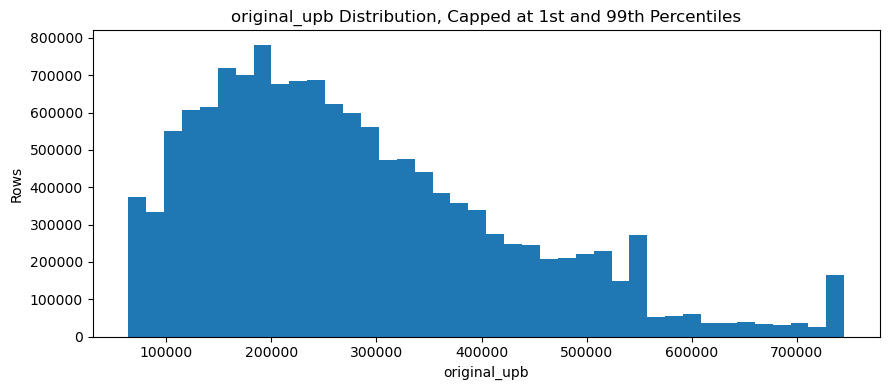

Saved: C:\Users\Esh\OneDrive\Documents\Mortgage Delinquency Forecasting Risk\outputs\2021q1_q2_sample10pct\plots\outlier_review_dti.png


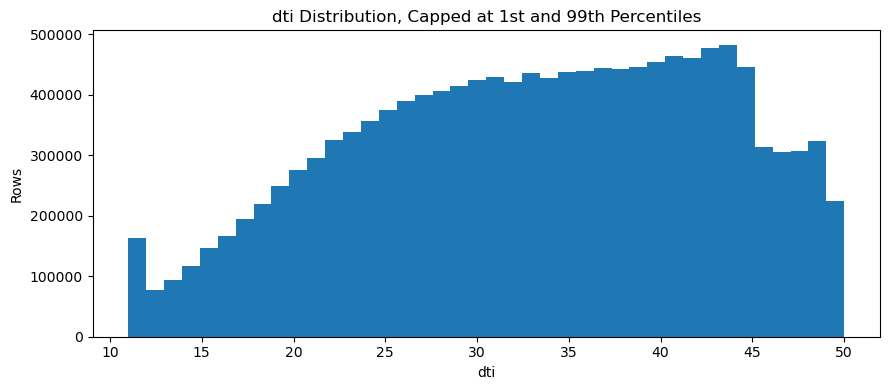

Saved: C:\Users\Esh\OneDrive\Documents\Mortgage Delinquency Forecasting Risk\outputs\2021q1_q2_sample10pct\plots\outlier_review_original_ltv.png


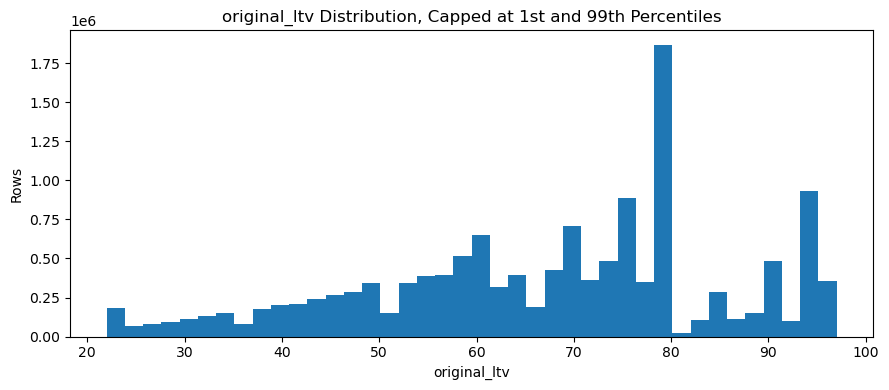

Saved: C:\Users\Esh\OneDrive\Documents\Mortgage Delinquency Forecasting Risk\outputs\2021q1_q2_sample10pct\plots\outlier_review_borrower_credit_score_at_origination.png


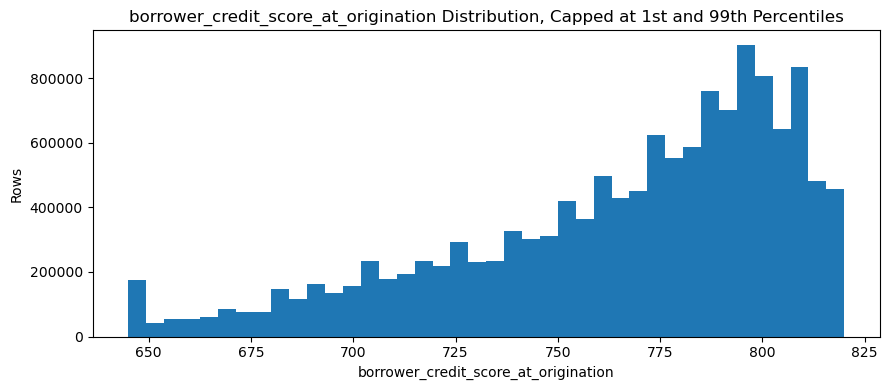

In [12]:
plot_outlier_features = [
    "original_upb",
    "dti",
    "original_ltv",
    "borrower_credit_score_at_origination"
]

for feature in plot_outlier_features:
    if feature not in labeled.columns or not should_plot_feature(labeled, feature):
        continue

    temp = capped_numeric_series(labeled[feature])

    if temp.empty:
        continue

    plt.figure(figsize=(9, 4))
    plt.hist(temp, bins=40)
    plt.title(f"{feature} Distribution, Capped at 1st and 99th Percentiles")
    plt.xlabel(feature)
    plt.ylabel("Rows")
    save_fig(f"outlier_review_{feature}.png")
    plt.show()

## 8. Feature selection notes and leakage review

I did not want to pick features only because they had the highest association score. Some variables can look very predictive because they are created after the borrower is already in trouble. Those fields would leak future information into the model.

For my first modeling pass, I would separate features into three groups:

- usable now,
- usable only after a time-availability check,
- drop before modeling.

The main rules I used were:

- remove IDs and constant fields,
- be careful with fields tied to foreclosure, zero-balance, disposition, or recovery events,
- avoid raw high-cardinality strings unless they are encoded carefully,
- only use performance variables if they are known at the monthly scoring date.


In [13]:
recommendation_rows = []

for _, row in feature_profile.iterrows():
    feature = row["feature"]
    semantic_type = row["semantic_type"]
    missing_pct = row["missing_pct_actual"]
    n_unique = row["n_unique_actual"]

    if feature == TARGET:
        recommendation = "target"
        reason = "Outcome variable, not a predictor."
    elif is_identifier_feature(feature):
        recommendation = "drop"
        reason = "Identifier or row key. It should not be used as a predictive signal."
    elif is_unmapped_field(feature):
        recommendation = "exclude_until_mapped"
        reason = "Raw field without a confirmed business definition."
    elif is_leakage_like_feature(feature):
        recommendation = "drop_or_audit_for_leakage"
        reason = "Potential post-event or future-outcome field."
    elif missing_pct >= 95:
        recommendation = "drop_or_keep_only_with_strong_reason"
        reason = "Mostly missing in the panel."
    elif n_unique <= 1:
        recommendation = "drop"
        reason = "No useful variation."
    elif semantic_type == "categorical" and n_unique > 200:
        recommendation = "encode_carefully"
        reason = "High-cardinality categorical field. Avoid unrestricted one-hot encoding."
    elif semantic_type in {"numeric", "low_cardinality_numeric", "categorical"}:
        recommendation = "candidate"
        reason = "Usable for modeling after preprocessing and leakage review."
    elif semantic_type == "date_or_time":
        recommendation = "engineer_or_use_for_splits"
        reason = "Use for time features or validation splits, not as a raw predictor."
    else:
        recommendation = "review"
        reason = "Needs manual review before modeling."

    recommendation_rows.append({
        "feature": feature,
        "eda_recommendation": recommendation,
        "reason": reason
    })

feature_recs = pd.DataFrame(recommendation_rows)

rec_cols = ["feature", "eda_recommendation", "reason"]
display(feature_recs[rec_cols])

numeric_rank = numeric_assoc.copy()
numeric_rank["association_score"] = numeric_rank[["pearson_abs_r", "spearman_abs_rho_sample"]].max(axis=1)
numeric_rank["cramers_v_sample"] = np.nan
numeric_rank["top_reliable_category_lift_vs_base_sample"] = np.nan

cat_rank = categorical_assoc.copy()
cat_rank["association_score"] = cat_rank["cramers_v_sample"]
cat_rank["pearson_abs_r"] = np.nan
cat_rank["spearman_abs_rho_sample"] = np.nan
cat_rank = cat_rank.rename(columns={"missing_pct": "missing_pct_actual", "n_unique_full": "n_unique_actual"})

numeric_rank = numeric_rank.rename(columns={"missing_pct": "missing_pct_actual", "n_unique": "n_unique_actual"})

candidate_ranking = pd.concat([numeric_rank, cat_rank], ignore_index=True, sort=False)

candidate_ranking = candidate_ranking.merge(
    feature_recs,
    on="feature",
    how="left"
)

candidate_ranking = candidate_ranking[
    candidate_ranking["feature"].map(is_main_feature_candidate)
].sort_values("association_score", ascending=False)

rank_cols = [
    "feature", "semantic_type", "association_score", "eda_recommendation", "reason",
    "pearson_abs_r", "spearman_abs_rho_sample", "cramers_v_sample",
    "top_reliable_category_lift_vs_base_sample", "missing_pct_actual", "n_unique_actual"
]

for col in rank_cols:
    if col not in candidate_ranking.columns:
        candidate_ranking[col] = np.nan

display(candidate_ranking[rank_cols].head(35))

feature_recs.to_csv(TABLES / "feature_recommendations.csv", index=False)
candidate_ranking.to_csv(TABLES / "candidate_ranking.csv", index=False)

,feature,eda_recommendation,reason
0,reference_pool_id,drop,Identifier or row key. It should not be used a...
1,loan_identifier,drop,Identifier or row key. It should not be used a...
2,monthly_reporting_period,engineer_or_use_for_splits,"Use for time features or validation splits, no..."
3,channel,candidate,Usable for modeling after preprocessing and le...
4,seller_name,candidate,Usable for modeling after preprocessing and le...
...,...,...,...
63,reporting_month,engineer_or_use_for_splits,"Use for time features or validation splits, no..."
64,reporting_quarter,engineer_or_use_for_splits,"Use for time features or validation splits, no..."
65,origination_year,engineer_or_use_for_splits,"Use for time features or validation splits, no..."
66,origination_quarter,engineer_or_use_for_splits,"Use for time features or validation splits, no..."


,feature,semantic_type,association_score,eda_recommendation,reason,pearson_abs_r,spearman_abs_rho_sample,cramers_v_sample,top_reliable_category_lift_vs_base_sample,missing_pct_actual,n_unique_actual
29,current_loan_delinquency_status,categorical,0.4204,candidate,Usable for modeling after preprocessing and le...,NaN,NaN,0.4204,223.6328,0.0000,3
0,current_dq_num,low_cardinality_numeric,0.3929,candidate,Usable for modeling after preprocessing and le...,0.3929,0.3156,NaN,NaN,0.0000,3
1,is_60plus_dq,low_cardinality_numeric,0.3855,candidate,Usable for modeling after preprocessing and le...,0.3749,0.3855,NaN,NaN,0.0000,2
2,is_30plus_dq,low_cardinality_numeric,0.3280,candidate,Usable for modeling after preprocessing and le...,0.3280,0.3149,NaN,NaN,0.0000,2
3,is_current,low_cardinality_numeric,0.3280,candidate,Usable for modeling after preprocessing and le...,0.3280,0.3149,NaN,NaN,0.0000,2
6,count_60plus_dq_past_12m,low_cardinality_numeric,0.2791,candidate,Usable for modeling after preprocessing and le...,0.2287,0.2791,NaN,NaN,0.0000,13
4,dq_status_worsened,low_cardinality_numeric,0.2755,candidate,Usable for modeling after preprocessing and le...,0.2755,0.2657,NaN,NaN,0.0000,2
5,count_30plus_dq_past_12m,low_cardinality_numeric,0.2726,candidate,Usable for modeling after preprocessing and le...,0.2726,0.1908,NaN,NaN,0.0000,13
8,prior_dq_num,numeric,0.2645,candidate,Usable for modeling after preprocessing and le...,0.1871,0.2645,NaN,NaN,2.0058,34
7,max_dq_past_12m,numeric,0.2084,candidate,Usable for modeling after preprocessing and le...,0.2084,0.1905,NaN,NaN,0.0000,34


## 9. What I learned from the EDA

The biggest thing I learned is that this is a heavily imbalanced classification problem. On the 2021Q1-Q2 panel, only about 0.24% of labeled rows become seriously delinquent within the next six months, which is even more imbalanced than my earlier sample run. So I should not judge the model with accuracy alone.

One new thing I caught while checking the target rate by reporting month is that the rate falls off sharply in the last few months of the panel. The monthly rate sits around 0.28% to 0.32% for most of 2024 and 2025, then slides toward 0.06% by November 2025. That drop is not real credit improvement. Rows near the end of the panel cannot see a full six months of future history, so some loans that do become seriously delinquent are still labeled 0. I am handling this in preprocessing by dropping reporting months that do not have a complete six-month window after them. This matters extra here because the chronological test split lands on the latest months.

The timeline check was also important. The gap file does not show missing months inside each loan's observed history, which makes the panel usable for lag features and rolling-window delinquency features.

The strongest signals are mostly current or recent performance variables. The fields I would test first are `current_dq_num`, `is_60plus_dq`, `is_30plus_dq`, `dq_status_worsened`, `count_30plus_dq_past_12m`, `count_60plus_dq_past_12m`, `prior_dq_num`, and `max_dq_past_12m`. These are only safe if they are available at the monthly scoring date.

The secondary candidates are the more standard mortgage-risk fields: credit score, remaining maturity, LTV/CLTV, DTI, interest rate, UPB/paydown variables, origination/reporting period, property state, channel, servicer, and seller. One note on co-borrower credit score: it is missing on about half the rows, but that missingness mostly means there is no co-borrower, and `number_of_borrowers` already carries that information.

I would drop or heavily audit foreclosure, zero-balance, disposition, recovery-cost, removal, and other post-event fields. Those can easily make the EDA look stronger than the real prediction problem.

For high-cardinality fields such as loan history strings, ZIP, MSA, seller, and servicer, I would not use unrestricted dummy variables. I would test frequency encoding, grouped rare levels, or target encoding inside cross-validation so the encoding does not leak target information.